---
## NOTEBOOK 2 VARIABLES ALEATORIAS
---

## Probabilidad Geométrica

### Ejemplo: Problema del encuentro

Dos personas planean encontrarse en un lugar especifico, en un rango de una hora $[0,60]$ minutos (1 hora).
 - Si A llega primero, entonces piensa esperar 10 minutos.
 - Si B llega primero, entonces piensa esperar 10 minutos

Se elige un número al azar entre $[0,60]$ y supongamos que el par de números se elige sobre el cuadrado de modo que la proobabilidad de un evento sea el área favorable entre el área total.

Sea

- $A$: las dos personas se encuentran a una distancia de 10 minutos.

Nos gustaría encontrar la probabilidad de $A$.



La probabilidad del evento A es: 0.30783.


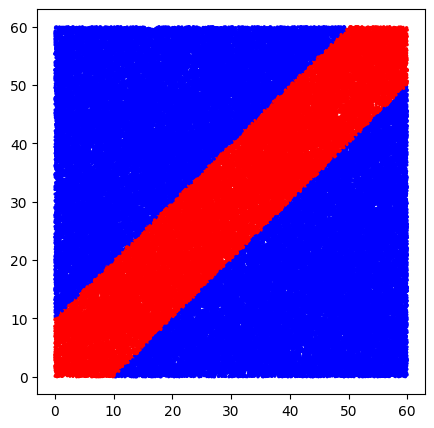

In [205]:
import numpy as np
import matplotlib.pyplot as plt # para graficos

# Vamos a generar 1000 simulaciones
muestra = 100000

# Generamos los tiempos aleatorios entre [0,60]
x = np.random.uniform(0, 60, muestra)
y = np.random.uniform(0, 60, muestra)

# Añadimos una condicion de encuentro
encuentro = np.where(abs(x-y) <= 10, 'r', 'b') # rojo si se encuentran, azul si no.

# Ahora calculamos la probabilidad de que se encuentren
k=0
for elemento in encuentro:
    if elemento == 'r': # los favorables
        k += 1 # lo añada
print("La probabilidad del evento A es: {}.".format(k/muestra))

# Graficamos
plt.figure(figsize=(5,5)) # tamaño de la figura
plt.scatter(x,y, c=encuentro, s=2)
plt.show()

In [206]:
import numpy as np # importamos Numpy
import numpy.random as npr # para generar numeros aleeatorios
import matplotlib.pyplot as plt # Para graficar
import scipy.stats as sps # distribuciones
from scipy.stats import bernoulli # importar cada distribución (añadir todas las distribuciones que vamos a usar)

# Variables aleatorias discretas


## Variable aleatoria uniforme discreta

Una variable aleatoria $X$ tiene distribución uniforme discreta en el conjunto $\{x_{1},\dots,x_{n}\}$ si su función de masa de probabilidades está dada por
$$f_{X}(k)=\mathbb{P}(X=k)=\begin{cases}
\frac{1}{n} &\quad \text{si } k\in\{x_{1},\dots,x_{n}\} \\
0 &\quad \text{en otro caso}
\end{cases}$$

**Notación:** $X\sim Unif(x_{1},\dots,x_{n}).$

Se llama uniforme porque cada uno de los posibles valores de $X$ tienen la misma probabilidad.

Si $X\sim Unif(x_{1},\dots,x_{n})$, en este caso, se tiene:
	$$\mathbb{E}[X] = \sum_{k}kf_{X}(k)=\frac{x_n + x_1}{2}.$$
	y
	$$\text{Var}(X) = \mathbb{E}[(X-\mathbb{E}[X])^{2}] =\sum_{k}(k-\mathbb{E}[X])^{2}f_{X}(k)=\frac{(x_n - x_1+1)^2-1}{12}$$

Ejercicio 1. Verifica que, en efecto, la esperanza y varianza de una variable uniforme está dada como antes.

--- DEMOSTRACIÓN SIMBÓLICA ---
E[X] simplificada: (x1 + xn)/2
¿Coincide con (x1 + xn)/2?: True

Var(X) simplificada: (x1 - xn)*(x1 - xn - 2)/12
¿Coincide con la fórmula teórica?: True

--- EJEMPLO NUMÉRICO (x1=1, xn=6) ---
Esperanza Numérica: 3.5000 | Esperanza Teórica: 3.5000
Varianza Numérica:  2.9167 | Varianza Teórica:  2.9167


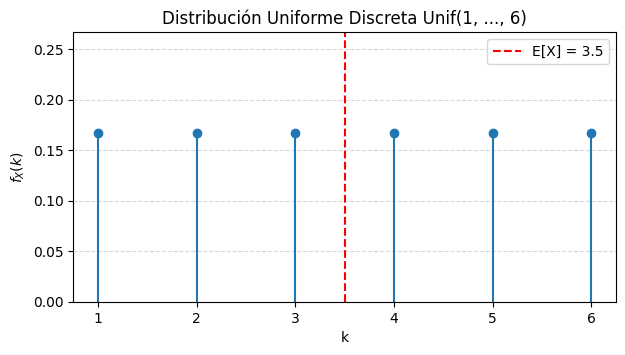

In [207]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Definimos los símbolos indicando que xn > x1
x1, xn, k = sp.symbols('x1 xn k', integer=True)
n_elem = xn - x1 + 1
x_k = x1 + k - 1

# Esperanza simbólica (fuerza la suma mediante la fórmula de suma finita)
suma_xk = sp.factor(sp.summation(x_k, (k, 1, n_elem)))
esperanza_simbolica = sp.factor((1 / n_elem) * suma_xk)

print("--- DEMOSTRACIÓN SIMBÓLICA ---")
print(f"E[X] simplificada: {esperanza_simbolica}")
print(f"¿Coincide con (x1 + xn)/2?: {sp.simplify(esperanza_simbolica - (x1 + xn)/2) == 0}")

# Varianza simbólica
diff_sq = sp.factor((x_k - esperanza_simbolica)**2)
suma_var = sp.factor(sp.summation(diff_sq, (k, 1, n_elem)))
varianza_simbolica = sp.factor((1 / n_elem) * suma_var)
formula_teorica = ((xn - x1 + 1)**2 - 1) / 12

print(f"\nVar(X) simplificada: {varianza_simbolica}")
print(f"¿Coincide con la fórmula teórica?: {sp.simplify(varianza_simbolica - formula_teorica) == 0}")

# Ejemplo: Dado de 6 caras (x1 = 1, xn = 6)
x1_val, xn_val = 1, 6
soporte = np.arange(x1_val, xn_val + 1)
pmf = np.ones_like(soporte, dtype=float) / len(soporte)

# Cálculos numéricos directos
exp_num = np.sum(soporte * pmf)
var_num = np.sum(((soporte - exp_num)**2) * pmf)

# Cálculos con fórmulas
exp_teorica = (x1_val + xn_val) / 2
var_teorica = ((xn_val - x1_val + 1)**2 - 1) / 12

print("\n--- EJEMPLO NUMÉRICO (x1=1, xn=6) ---")
print(f"Esperanza Numérica: {exp_num:.4f} | Esperanza Teórica: {exp_teorica:.4f}")
print(f"Varianza Numérica:  {var_num:.4f} | Varianza Teórica:  {var_teorica:.4f}")

# Gráfica (usando .max() de NumPy)
plt.figure(figsize=(7, 3.5))
plt.stem(soporte, pmf, basefmt=" ")
plt.axvline(exp_num, color='r', linestyle='--', label=f'E[X] = {exp_num}')
plt.title(f'Distribución Uniforme Discreta Unif({x1_val}, ..., {xn_val})')
plt.xlabel('k')
plt.ylabel('$f_X(k)$')
plt.ylim(0, pmf.max() + 0.1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Ejemplo** Se lleva a cabo una rifa donde los boletos están enumerados del $00$ al $99$. Si $Y$ es la variable aleatoria definida como el número del boleto ganador, entonces:  
$$\mathbb{P}(Y=k)=\begin{cases}
	\frac{1}{100} &\quad \text{si } k=00,01,\dots,99 \\
	0 &\quad \text{en otro caso}
\end{cases}$$
Consideremos que el premio de la rifa se determina a partir del número premiado de la siguiente forma: $X=Y+1$, donde $X$ es el monto del premio en pesos y $Y$ es el número premiado, entonces $X$ es una variable aleatoria, pues es una función de $Y$, y además se tiene
	$$f_{X}(k)=\begin{cases}
		\frac{1}{100} &\quad \text{si } x=1,2,\dots,100 \\
		0 &\quad \text{en otro caso}
	\end{cases}$$
Entonces, la esperanza y varianza de $X$ están dados por:
	$$\mathbb{E}[X] = \sum_{k=1}^{100}k\left(\frac{1}{100}\right) = \frac{1}{100}\sum_{k=1}^{100}k = \frac{1}{100}\left[\frac{100(100+1)}{2}\right] = 50.5$$
	y
	$$\text{Var}(X) = \mathbb{E}[X^{2}]-(\mathbb{E}[X])^{2} = \sum_{k=1}^{100}k^{2}\left(\frac{1}{100}\right)-(50.5)^{2} = 833.25$$   


    
Supongamos que nos interesa calcular la probabilidad de que el premio sea mayor a $\$80$, entonces
	$$\mathbb{P}(X>80) = \mathbb{P}(X=81)+\cdots+\mathbb{P}(X=100) =  \sum_{k=81}^{100}\frac{1}{100} = \frac{20}{100} = 0.2$$
	Su función de distribución esta dada por:
	$$F_{X}(x)=\mathbb{P}(X\le x)=\begin{cases}
		0 &\quad \text{si } x<1 \\
		\frac{x}{100} &\quad \text{si } x=1,2,\dots,100\\ 1 &\quad \text{si } x>100
	\end{cases}$$     

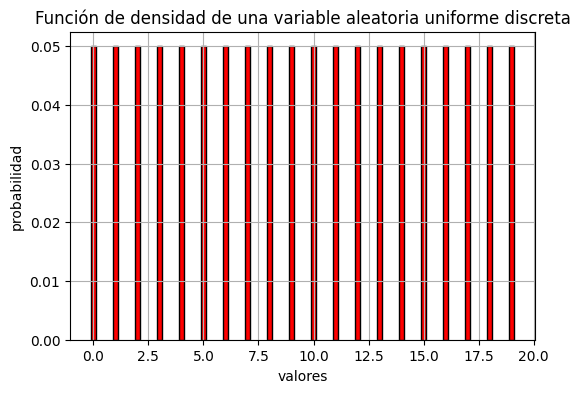

In [208]:
# Distribución uniforme discreta
min = 0
max = 20
x = np.arange(min, max)

# Vamos a crear la función de densidad (pmf (probability mass function))
pmf_unif = np.full_like(x, 1/(max-min), dtype=float) # crear un arreglo del mismo tamaño

#Graficamos la función de densidad
plt.figure(figsize=(6,4))
plt.bar(x, pmf_unif, width=0.2, color='r', edgecolor='black') # grafica de barras
plt.xlabel("valores")
plt.ylabel("probabilidad")
plt.title("Función de densidad de una variable aleatoria uniforme discreta")
plt.grid(True)
plt.show()

## Variable aleatoria Bernoulli con parámetro $p\in (0,1)$.

El modelo probabilístico Bernoulli se aplica a un experimento cuyo espacio muestral está constituido sólo por dos resultados posibles, éxito y fracaso:

Se considerará una v.a $X$ sobre el espacio muestral $$\Omega=\{\text{éxito, fracaso}\}$$
de tal forma que
* $X(\{\text{éxito}\}) = 1$
* $X(\{\text{fracaso}\}) = 0$

Las probabilidades asociadas a este modelo son:

* $\mathbb{P}(\{\text{éxito}\}) = p$
* $\mathbb{P}(\{\text{fracaso}\}) = 1-p$

donde $0<p<1$.


Entonces la función de densidad de masa de probabilidades de $X$ está dada por:

$$f_{X}(k)=\begin{cases}
p &\quad \text{si } k=1 \\
1-p &\quad \text{si } k=0
\end{cases}$$

**Notación:** $X\sim \text{Ber}(p)$.

Esta variable aleatoria es muy importante. En la practica es usada para modelar situaciones en las cuales hay dos posibles resultados como:
* el estado de un teléfono en un momento dado: libre u ocupado.
* una persona pueda estar enferma o sana de una determinada enfermedad.
* la preferencia de una persona, la cual puede estar a favor o en contra de un candidato determinado.

Mediante la combinación de variables aleatorias Bernoulli es posible construir otras variables aleatorias.

### Esperanza y Varianza

Si $X\sim \text{Ber}(p)$, entonces su esperanza es:
\begin{align*}
\mathbb{E}[X] = \sum_{k=0}^{1}kf_{X}(k) = 1\cdot p + 0\cdot (1-p) = p.
\end{align*}

Y su varianza se calcula usando,
$$\mathbb{E}[X^{2}] = \sum_{k=0}^{1}k^{2}f_{X}(k) = 1^{2}\cdot p + 0^{2}\cdot (1-p) = p.$$
Por lo tanto,
$$\text{Var}(X)=\mathbb{E}[X^{2}]-(\mathbb{E}[X])^{2} = p-p^{2} = p(1-p)$$



La función de densidad es: [0.4 0.6]


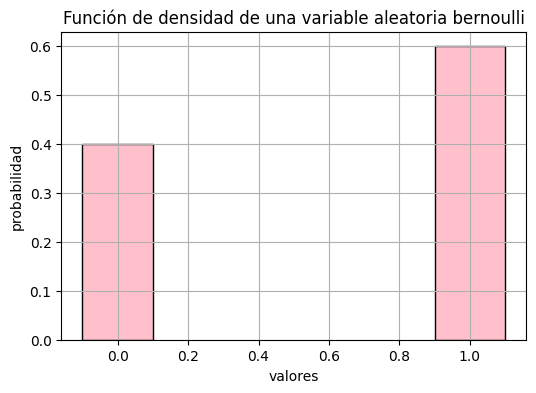

In [209]:
# Grafica de la distribución Bernoulli
# Definir mi probabilidad de éxito
p= 0.6 # éxito

# Defino los posibles valores de la variable aleatoria
x = [0,1]

# Calcular la función de masa de probabilidad
pmf_ber = bernoulli.pmf(x,p)

print("La función de densidad es:", pmf_ber)

# Graficamos la función de densidad
plt.figure(figsize=(6,4))
plt.bar(x, pmf_ber, width = 0.2, color = "pink", edgecolor = "k")
plt.xlabel("valores")
plt.ylabel("probabilidad")
plt.title("Función de densidad de una variable aleatoria bernoulli")
plt.grid(True)
plt.show()

In [210]:
media = bernoulli.mean(p) # esperanza
varianza = bernoulli.var(p) # varianza
print("La esperanza es:", media)
print("La varianza es:", varianza)

La esperanza es: 0.6
La varianza es: 0.24


## Variable aleatoria Binomial con parámetros $n$ y $p\in (0,1)$.

Decimos que una v.a $X$ tiene distribución binomial con párametros $n$ y $p$, si su función de densidad de masa de probabilidades está dada por:
$$\begin{equation*}
	f_{X}(k)= \mathbb{P}(X=k)= \begin{cases}
	\binom{n}{k}p^{k}(1-p)^{n-k} &\quad \text{si } k=0,1,\dots,n \\
	\qquad 0 &\quad \text{en otro caso}  
	\end{cases}
\end{equation*}$$
donde $n$ es un entero positivo y $0< p< 1$.

La esperanza de $X$ es:
\begin{align*}
\mathbb{E}[X]&= \sum_{k \mathop = 0}^n k \binom n k p^k (1-p)^{n - k}\\
&=\sum_{k \mathop = 1}^n k \binom n k p^k (1-p)^{n - k}\\
&= \sum_{k \mathop = 1}^n n \binom {n - 1} {k - 1} p^k (1-p)^{n - k}\\
&= n p \sum_{k \mathop = 1}^n \binom {n - 1} {k - 1} p^{k - 1} (1-p)^{( {n - 1}) - ( {k - 1}) }\\
&=n p \sum_{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j}\\
&=np
\end{align*}

Ahora,
\begin{align*}
\mathbb{E}[X^2]&= \sum_{k \mathop = 0}^n k^2 \binom n k p^k (1-p)^{n - k}\\
&=\sum_{k \mathop = 0}^n k n \binom {n - 1} {k - 1} p^k (1-p)^{n - k}\\
&= n p \sum_{k \mathop = 1}^n k \binom {n - 1} {k - 1} p^{k - 1} (1-p)^{({n - 1}) - ({k - 1}) }\\
&= n p \sum_{j \mathop = 0}^m ({j + 1}) \binom m j p^j (1-p)^{m - j}\\
&=n p \left( {\sum_{j \mathop = 0}^m j \binom m j p^j (1-p)^{m - j} + \sum_{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j} }\right)\\
&=n p \left( {\sum_{j \mathop = 0}^m m \binom {m - 1} {j - 1} p^j (1-p)^{m - j} + \sum_{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j} }\right)\\
&= n p \left( (n - 1) p \sum_{j \mathop = 1}^m \binom {m - 1}{j - 1} p^{j - 1} (1-p)^{( {m - 1}) - ({j - 1}) } + \sum_{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j}\right) \\
&= n p \left( (n - 1) p (p + (1-p))^{m - 1} + (p + (1-p))^m\right)\\
&= n p ((n - 1) p + 1)\\
&= (np)^2 +np(1-p),
\end{align*}

por lo que la varianza de $X$ es:
$$\text{Var}(X)=np(1-p).$$

**Ejemplo** Una moneda no justa se tira 6 veces, donde la probabilidad de obtener sol es de $0.3$.

Sea $X$ el número de veces que cae sol, entonces $X$ tiene una distribución binomial con parámetros $n=6$ y $p=0.3$. Por lo que
$$\begin{align*}
\mathbb{P}(X=2) &= \binom{6}{2}(0.3)^{2}(0.7)^{4}=0.3241 \\
\mathbb{P}(X=3) &= \binom{6}{3}(0.3)^{3}(0.7)^{3}=0.1852 \\
\mathbb{P}(1<X\le 5) &= \mathbb{P}(X=2)+\mathbb{P}(X=3)+\mathbb{P}(X=4)+\mathbb{P}(X=5) \\
			&= 0.3241 + 0.1852 + \binom{6}{4}(0.3)^{4}(0.7)^{2} + \binom{6}{5}(0.3)^{5}(0.7)^{1} \\
			&= 0.5093 + 0.0595 + 0.0102 = 0.579
\end{align*}$$

Note que la probabilidad $$\mathbb{P}(1<X\leq 5)=F_{X}(5)-F_{X}(1).$$

In [211]:
from scipy.stats import binom
# Proba de que haya 5 o menos éxitos en 6 ensayos
F5 = binom.cdf(5,6,0.3) # x=5, n=6, p=0.3

# Proba de que haya 1 o menos éxitos en 6 ensayos
F1 = binom.cdf(1,6,0.3) # x=1, n=6, p=0.3
F5-F1

np.float64(0.5790960000000003)

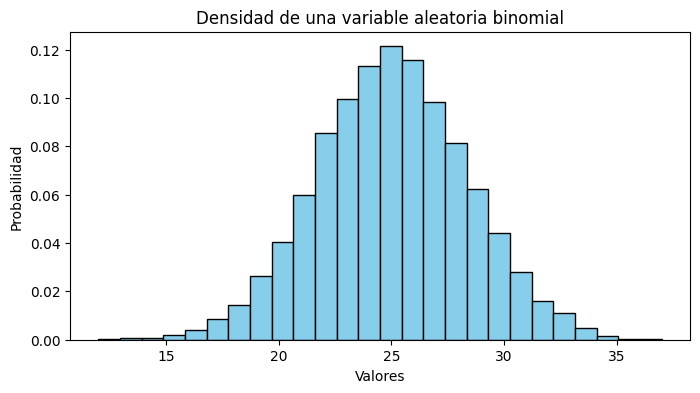

In [212]:
# Grafica de la distribución Binomial
# Parámetros
n = 50
p = 0.5

# Generamos numeros aleatorios con distribución binomial
binom_numeros = sps.binom.rvs(n,p,size = 10000)

# Creamos un histograma
plt.figure(figsize=(8,4))
plt.hist(
    binom_numeros,
    density = True, # normaliza para que sea función de densidad
    bins = len(np.unique(binom_numeros)), # numero de barras en el histograma
    color = "skyblue",
    edgecolor = 'k'
)
plt.xlabel('Valores')
plt.ylabel('Probabilidad')
plt.title('Densidad de una variable aleatoria binomial')
plt.show()

## Variable aleatoria Poisson

Es una distribución de probabilidad discreta que  sirve para calcular la probabilidad de que ocurra un determinado **número de eventos raros** durante un intervalo dado (puede ser de tiempo, longitud, área, etc.

Esta variable aleatoria toma los valores sobre el conjunto $\{0,1,2,\dots\}$ y tiene un parámetro $\lambda>0$, el cual representa el número de veces que se **espera** que ocurra un evento durante un intervalo dado.

La función de masa de probabilidades de una variable aleatoria Poisson, $X$, está dada por:
$$f_{X}(k)=\begin{cases}
	e^{-\lambda}\frac{\lambda^{k}}{k!} &\quad \text{si } k=0,1,2,\dots \\
	0 &\quad \text{en otro caso}  
\end{cases}$$

En efecto, es una función de masa de probabilidades debido a que
$$\begin{align*}
\sum_{k=0}^{\infty}e^{-\lambda}\frac{\lambda^{k}}{k!} &= e^{-\lambda}\sum_{k=0}^{\infty}\frac{\lambda^{k}}{k!} \\ &= e^{-\lambda}\underbrace{\left(1+\lambda+\frac{\lambda^{2}}{2!}+\frac{\lambda^{3}}{3!}+\cdots\right)}_{\text{desarrollo de Taylor de }e^{\lambda}} \\ &= e^{-\lambda}e^{\lambda}=1.
\end{align*}$$

Se tiene que $\mathbb{E}[X] = \lambda$ y $\text{Var}(X)= \lambda$.

**Aplicaciones**

**Ejemplo:** Supongamos que el número de accidentes que ocurre en un punto tiene una distribución Poisson con parámetro $\lambda=2$.
* ¿Cuál es la probabilidad de que en un día ocurran más de dos accidentes?
  $$
  \begin{align*}
	\mathbb{P}(X>2) &= 1-\mathbb{P}(X\le 2) \\ &=1-\left[\mathbb{P}(X=0)+\mathbb{P}(X=1)+\mathbb{P}(X=2)\right] \\ &= 1-\left[\frac{e^{-2}2^{0}}{0!}+\frac{e^{-2}2^{1}}{1!}+\frac{e^{-2}2^{2}}{2!}\right] \\ &= 1-e^{-2}\left[1+2+2\right] = 1-5e^{-2} = 0.3233
  \end{align*}
  $$

* ¿Cuál es la probabilidad de que en un día ocurran más de dos accidentes, sabiendo que ocurre por lo menos uno?
$$\begin{align*}
\mathbb{P}(X>2 \mid X\ge 1) = \frac{\mathbb{P}(X>2 \cap X\ge 1)}{\mathbb{P}(X\ge 1)} = \frac{\mathbb{P}(X>2)}{\mathbb{P}(X\ge 1)} = \frac{1-\mathbb{P}(X\leq 2)}{1-\mathbb{P}(X<1)} = \frac{1-5e^{-2}}{1-e^{-2}} = \frac{0.3233}{0.8646} = 0.3739
\end{align*}$$
ya que $\mathbb{P}(X\ge 1)=1-\mathbb{P}(X<1)=1-\mathbb{P}(X=0)=1-e^{-2}$

Calculando las probabilidades anteriores usando el atributo `.cdf`

In [213]:
from scipy.stats import poisson

In [214]:
# Sea el parametro lambda = 2
lamb = 2 # lambda es una palabra reservada

# Probabilidad de más de dos accidentes
prob_mas2 = 1 - poisson.cdf(2,lamb)

print("P(X>2) =",prob_mas2)
print("La probabilidad de que ocurran más de dos accidenrtes es: ",prob_mas2)

# Proba condicional
p_mas2_dado_uno = prob_mas2 / (1 - poisson.cdf(0,lamb))
p_mas2_dado_uno

print("P(X>2 | X >= 1) =",p_mas2_dado_uno)

P(X>2) = 0.3233235838169366
La probabilidad de que ocurran más de dos accidenrtes es:  0.3233235838169366
P(X>2 | X >= 1) = 0.37392942900133747


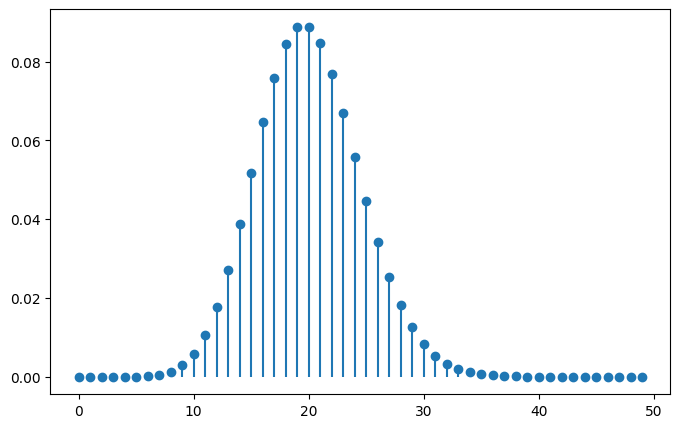

In [215]:
# Grafica de la densidad Poisson
x = np.arange(0,50)
y = poisson.pmf(x,20)

plt.figure(figsize=(8,5))
plt.vlines(x,0,y) #lineas verticales
plt.plot(x,y,'o')
plt.show()


## Aproximación de Poisson a la Binomial
La distribución de Poisson es una forma límite de la distribución binomial, es decir, es una buena aproximación cuando $n$ es suficientemente grande y $p$ suficientemente pequeña.

$\textbf{Teorema (Poisson).-}$ Sean $S_{n}\sim Bin(n,p_{n})$ bajo el regimen $$\lim_{n\to \infty}np_{n}=\lambda>0.$$
Consideremos la siguiente sucesión de números reales:
$$a_{j}(n,p_n)=\begin{cases}\binom{n}{j}(p_n)^{j}(1-p_{n})^{n-j} & j\leq n\\
0 & j\geq n+1\end{cases}$$

 Entonces,
 $$\lim_{n\to \infty}a_{j}(n,p_n)=a_{j}=e^{-\lambda}\frac{\lambda^{j}}{j!} \ \ \forall j\in \mathbb{N}.$$

 El teorema anterior implica que la distribución de Poisson ofrece un modelo probabilístico adecuado para todos aquellos experimentos aleatorios 	en los que las repeticiones son independientes unas de otras y en los 	que sólo hay dos posibles resultados: éxito o fracaso, con probabilidad de 	éxito pequeña, y en los que el interés se centra en conocer el número de éxitos obtenidos al realizar el experimento un número suficientemente grande de veces.

Empíricamente se ha establecido, que la aproximación se puede aplicar con seguridad si $n\ge100$, $p\le 0.01$ y $np \le20$.

**Ejemplo** Supongamos que la probabilidad de que un producto producido por cierta máquina es defectuoso es de $0.1$. ¿Cuál es la probabilidad de que un lote de 10 productos contenga a lo más un producto defectuoso?

Sea $X$ el número de productos defectuosos, y sabemos que $X$ tiene una distribución binomial con parámetros $n=10$ y $p=0.1$, entonces
\begin{align*}
\mathbb{P}(X\le 1) &= \mathbb{P}(X=0)+\mathbb{P}(X=1) \\ &= \binom{10}{0}(0.1)^{0}(0.9)^{10-0}+\binom{10}{1}(0.1)^{1}(0.9)^{10-1} \\ &= 0.7361
	\end{align*}

Ahora, con la distribución Poisson, tenemos que $\lambda=10(0.1)=1$, por lo que
$$\mathbb{P}(X\le 1) = \mathbb{P}(X=0)+\mathbb{P}(X=1) = \frac{e^{-1}1^{0}}{0!}+\frac{e^{-1}1^{1}}{1!} = e^{-1}+e^{-1} =0.7358$$

## Variable aleatoria Geométrica con parámetro $p\in (0,1)$.

Esta variable aleatoria cuenta el número de fracasos antes del primer éxito en ensayos bernoulli independientes con parámetro $0<p<1$, y su función de masa de probabilidades está dada por:
$$f_{X}(k)=\begin{cases}
	p(1-p)^{k-1} &\quad \text{si } k=1,2,\dots \\
	\qquad 0 &\quad \text{en otro caso}  
\end{cases}$$


Notación. $X\sim Geo(p)$

La cual es una función de densidad ya que:
* $0\le f_{X}(k)\le 1$ para toda $x$.
* $$\begin{align*}
	\sum_{k\in R_{X}}f_{X}(k) &= \sum_{k=1}^{\infty}(1-p)^{k-1}p \\
			&= p\sum_{y=0}^{\infty}(1-p)^{y} \\
			&= p\left(\frac{1}{1-(1-p)}\right) = 1
		\end{align*}$$

Si por el contrario queremos contar el número de éxitos antes del primer fracaso, tenemos que la función de está dada por:
	$$f_{X}(k)=\begin{cases}
		p^{k}(1-p) &\quad \text{si } k=0,1,2,\dots \\
		\qquad 0 &\quad \text{en otro caso}  
	\end{cases}$$

Para calcular la Esperanza y Varianza de $X$, necesitamos del siguiente lema:

**Lema 1** Sea $x$ un número real tal que $│x│<1$. Entonces,
$$\sum_{k=1}^{\infty}kx^{k-1}=\frac{1}{(1-x)^2}.$$
**Demostración.** Se tiene que
$$\frac{d}{dx}\sum_{k=1}^{\infty}x^{k}=\sum_{k=1}^{\infty}kx^{k-1}.$$
Además,
$$\sum_{k=1}^{\infty}x^{k}=\frac{x}{1-x}.$$
Por lo tanto,
$$\frac{d}{dx}\frac{x}{1-x}=\frac{1}{(1-x)^2}.$$

Como corolario,
$$\sum_{k=1}^{\infty}k(k+1)x^{k-1}=\frac{2}{(1-x)^2}.$$
En efecto,
$$\frac{d}{dx}\sum_{k=1}^{\infty}(k+1)x^{k}=\sum_{k=1}^{\infty}k(k+1)x^{k-1}.$$
Ahora,
$$\sum_{k=1}^{\infty}(k+1)x^{k}=\sum_{m=2}^{\infty}mx^{m-1}=\frac{1}{(1-x)^2}-1.$$

Usando estos resultados, la esperanza de $X$ es:
\begin{align*}
\mathbb{E}[X]&=  \sum_{x \mathop \ge 1} k p(1-p)^{k - 1}\\
&= p \frac 1 {(1 - (1-p))^2}\\
&=  \frac p {p^2}\\
&=\frac{1}{p}
\end{align*}

Calculamos,
\begin{align*}
\mathbb{E}[X^2]&= \sum_{k=1}^{\infty} x^{2}p(1-p)^{k-1}\\
&=\sum_{k=1}^{\infty}k(k+1)(1-p)^{k-1}p-\sum_{k=1}^{\infty}p(1-p)^{k-1}
\end{align*}

Por el Lema 1,
$$\mathbb{E}[X^2]=p\frac{2}{p^3}-\frac{1}{p}=\frac{2}{p^2}-\frac{1}{p}.$$

Por lo tanto,
$$\text{Var}(X)=\frac{2}{p^2}-\frac{1}{p}-\frac{1}{p^2}=\frac{1-p}{p^2}.$$

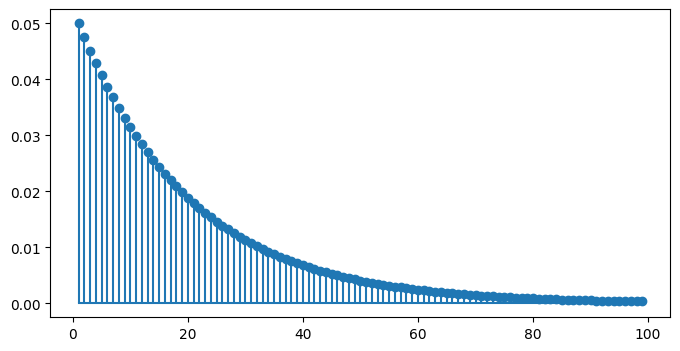

In [216]:
# Ahora vamos a graficar la distribución geometrica

from scipy.stats import geom

# El parámetro es
p = 0.05

#Valores posibles
x = np.arange(1,100) # de 1 a 20 ensayos

pmf_geo = geom.pmf(x,p)

plt.figure(figsize=(8,4))
plt.stem(x,pmf_geo, basefmt="") # baras verticales
plt.show()

# Variable Aleatoria Binomial Negativa $X \sim \text{BN}(r, p)$

La distribución **Binomial Negativa** describe procesos donde el número de éxitos está predeterminado ($r$), y nuestra incertidumbre recae sobre cuántos intentos totales ($X$) necesitaremos realizar para alcanzar dicha meta.

Supongamos que se realizan ensayos independientes, cada uno con probabilidad $0<p<1$ de ser un éxito, hasta obtener un total de $r$ éxitos acumulados. Sea $X$ el número de ensayos que se requieren, entonces la probabilidad de que el éxito número $r$ ocurra exactamente en el ensayo $k$ es:

$$f_{X}(k) = \binom{k-1}{r-1} p^r (1-p)^{k-r}$$

Donde:
- El valor de $k$ pertenece al conjunto $\{r, r+1, r+2, \dots\}$.
- El parámetro de Forma ($r$): representa el número de éxitos acumulados que deseamos obtener ($r \geq 1$).
- El parámetro de Intensidad ($p$): es la probabilidad de éxito en cada ensayo independiente ($0 < p < 1$).

El valor promedio esperado de ensayos totales es:
$$\mathbb{E}[X] = \frac{r}{p}$$
 Y la varianza mide la dispersión de los ensayos necesarios:
$$\text{Var}[X] = \frac{r(1-p)}{p^2}$$

## Aplicaciones en Ciencia de Datos y Estadística

### 1. Control de Calidad y Procesos Industriales

Imagina que eres un ingeniero en una fábrica y necesitas recolectar **10 piezas defectuosas** $r = 10$ para analizar por qué fallan. Si sabes que la probabilidad de que una pieza salga mal es $p = 0.01 $:

- **¿Para qué sirve?** Para calcular cuántas piezas totales tendrás que inspeccionar en promedio antes de completar tu muestra.

- **Cálculo:** $$\mathbb{E}[X] = 10 / 0.01 = 1{,}000 $$ piezas. Esto te ayuda a presupuestar el tiempo de inspección.

### 2. Estrategias de Marketing y Ventas

Un vendedor necesita cerrar **5 ventas** $r = 5$ para llegar a su cuota diaria. Por experiencia, sabe que tiene una probabilidad de éxito del 20%, es decir, $p = 0.2$ por cada llamada.

- **¿Para qué sirve?** Para determinar cuántas llamadas debe hacer. El modelo le dirá que en promedio hará 25 llamadas, pero la **Varianza** le advertirá que hay días "malos" donde podría necesitar 40 o 50 llamadas para lograr el mismo objetivo.

### 3. Epidemiología y Salud Pública

Se usa para modelar el número de personas expuestas a un virus hasta que se encuentran $r$ casos positivos.

- **¿Para qué sirve?** Ayuda a entender la propagación de enfermedades. Si el virus es muy contagioso ($p$ alta), llegaremos a los $r$ casos rápido. Si la varianza es alta, la enfermedad es impredecible ("super-propagadores").

### 4. Modelado de "Sobredispersión" (Uso Avanzado)

En estadística de datos (Data Science), muchas veces usamos la **Binomial Negativa** cuando la **Distribución de Poisson** falla.

- En Poisson, la media es igual a la varianza.

- En la vida real (como clics en un anuncio o llegadas de clientes), la varianza suele ser mucho mayor que la media. La Binomial Negativa permite ajustar modelos donde los datos están muy dispersos.

### 5. Modelado de Tiempos de Espera

Se usa para predecir cuándo se completará una muestra de datos (ej. "necesitamos 100 encuestas válidas, ¿cuánta gente debemos contactar?").

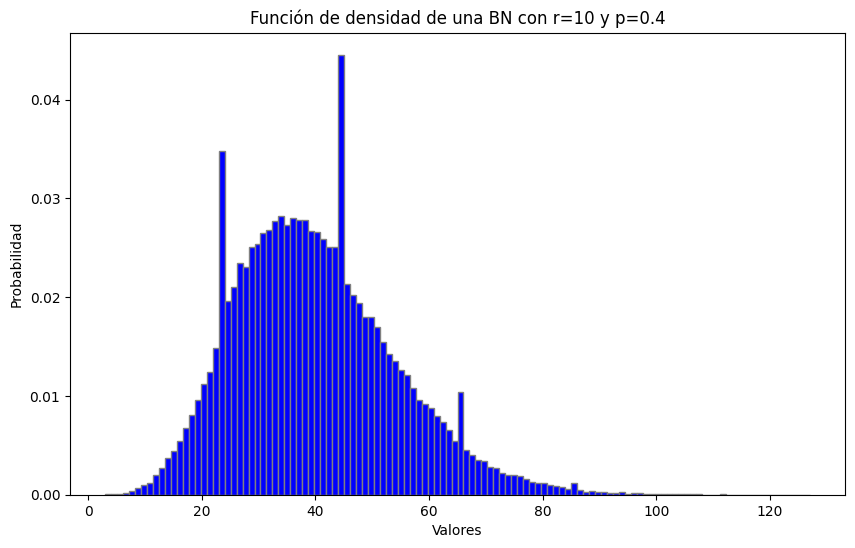

In [217]:
r = 10
p = 0.2 # probabilidad de éxito
s= 100000 # número de muestras

np.random.seed(3) #fijar una semilla (para reproducilibilidad)
#Vamos a generar numeros aleatorios que siguen una distribución BN
nbinom_numeros = sps.nbinom.rvs(r,p,size=s)

#Creamos un histograma
plt.figure(figsize=(10,6))
plt.hist(
    nbinom_numeros,
    density=True, # Normaliza el area para que sea 1
    bins=len(np.unique(nbinom_numeros)), # número de barras del histograma
    color = "blue",
    edgecolor="grey"
)

plt.xlabel('Valores')
plt.ylabel('Probabilidad')
plt.title('Función de densidad de una BN con r=10 y p=0.4')
plt.show() #mostrar el gráfica

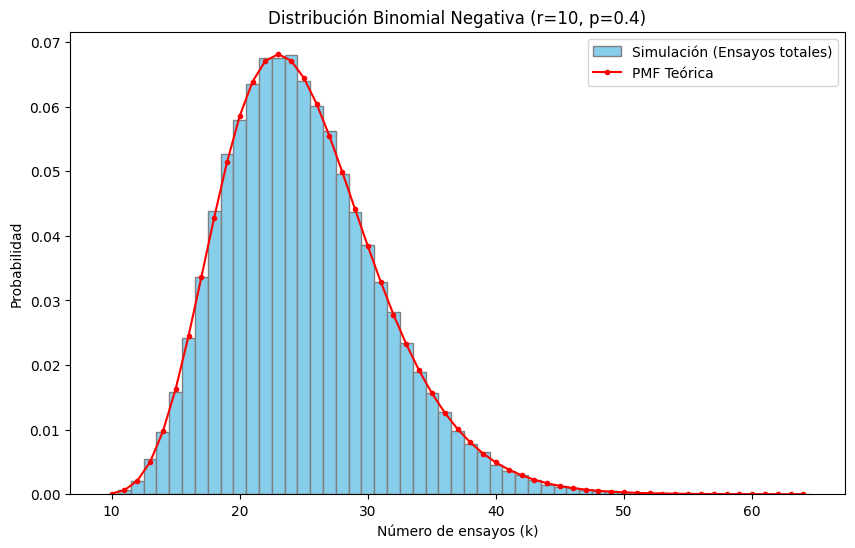

In [218]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
import random

r = 10
p = 0.4
s = 100000

np.random.seed(3) # Es preferible usar np.random.seed para funciones de numpy/scipy

# 1. Generamos los fracasos y SUMAMOS r para obtener ensayos totales
nbinom_fracasos = sps.nbinom.rvs(r, p, size=s)
nbinom_ensayos = nbinom_fracasos + r

# 2. Creamos el histograma
plt.figure(figsize=(10,6))
plt.hist(
    nbinom_ensayos,
    density=True,
    bins=np.arange(r, np.max(nbinom_ensayos) + 1) - 0.5, # Centramos las barras
    color="skyblue",
    edgecolor="grey",
    label='Simulación (Ensayos totales)'
)

# 3. Superponemos la PMF teórica para validar
x_teorico = np.arange(r, np.max(nbinom_ensayos))
# Usamos x_teorico - r porque la PMF de scipy pide fracasos
pmf_teorica = sps.nbinom.pmf(x_teorico - r, r, p)

plt.plot(x_teorico, pmf_teorica, 'ro-', markersize=3, label='PMF Teórica')

plt.xlabel('Número de ensayos (k)')
plt.ylabel('Probabilidad')
plt.title(f'Distribución Binomial Negativa (r={r}, p={p})')
plt.legend()
plt.show()

Ejercicio 2. Un examen de Estadística consta de 20 preguntas tipo test y se conoce de experiencias
anteriores que un alumno tiene probabilidad 0.7 de contestar bien cada pregunta. Obtener:

a) La probabilidad de que la primera pregunta que contesta bien sea la cuarta.

b) Sabiendo que para aprobar el examen es necesario contestar bien a 10 preguntas, ¿cuál es la probabilidad de que apruebe al contestar la pregunta duodécima?



--- EJERCICIO 2 ---
a) Probabilidad de 1er éxito en la 4ª pregunta: 0.0189
b) Probabilidad de 10º éxito en la 12ª pregunta: 0.1398

--- EJERCICIO 3 (BANACH) ---
Ejemplo con N = 50:
Probabilidad de que la otra caja esté también vacía (k=0): 0.0796
Probabilidad de que queden 5 cerillos (k=5): 0.0717


<>:41: SyntaxWarning:

invalid escape sequence '\m'

<>:41: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_731/4159618176.py:41: SyntaxWarning:

invalid escape sequence '\m'



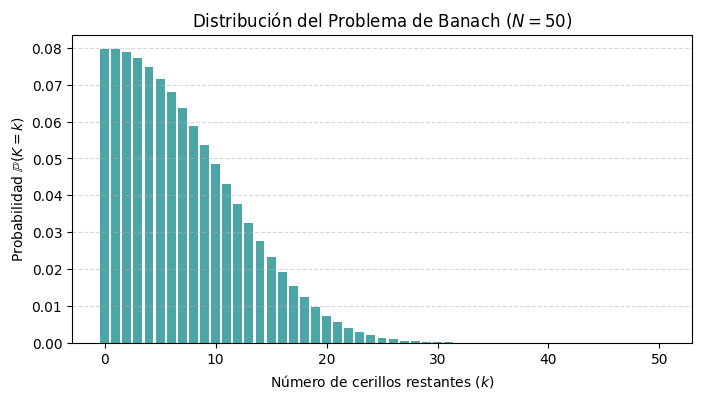

In [219]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import geom, nbinom

p = 0.7

# a) Primera correcta en la 4a pregunta (Geométrica)
prob_a = geom.pmf(4, p) # (1-p)**3 * p

# b) Aprobar (10 aciertos) en la 12a pregunta (Binomial Negativa)
# scipy nbinom(k, r, p) mide fracasos k antes de r éxitos.
# Si el ensayo total es 12 y r=10 éxitos -> fracasos k = 12 - 10 = 2.
prob_b = nbinom.pmf(2, 10, p)

print("--- EJERCICIO 2 ---")
print(f"a) Probabilidad de 1er éxito en la 4ª pregunta: {prob_a:.4f}")
print(f"b) Probabilidad de 10º éxito en la 12ª pregunta: {prob_b:.4f}\n")



def prob_banach(N, k):
    """Calcula la probabilidad de que queden k cerillos cuando una caja se descubre vacía."""
    comb = math.comb(2*N - k, N)
    return comb * (0.5**(2*N - k))

N = 50 # Ejemplo con N = 50 cerillos por caja
k_valores = np.arange(0, N + 1)
probabilidades = [prob_banach(N, k) for k in k_valores]

print("--- EJERCICIO 3 (BANACH) ---")
print(f"Ejemplo con N = {N}:")
print(f"Probabilidad de que la otra caja esté también vacía (k=0): {prob_banach(N, 0):.4f}")
print(f"Probabilidad de que queden 5 cerillos (k=5): {prob_banach(N, 5):.4f}")

# Gráfica de la distribución del problema de Banach
plt.figure(figsize=(8, 4))
plt.bar(k_valores, probabilidades, color='teal', alpha=0.7)
plt.title(f'Distribución del Problema de Banach ($N = {N}$)')
plt.xlabel('Número de cerillos restantes ($k$)')
plt.ylabel('Probabilidad $\mathbb{P}(K = k)$')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Ejercicio 3. Investigue sobre el problema de la caja de cerillos de Banach y explique su solución (sin simulación).


El matemático Stefan Banach llevaba consigo dos cajas de cerillos (fósforos), una en el bolsillo derecho y otra en el bolsillo izquierdo. Inicialmente, cada caja contenía $N$ cerillos.

Cada vez que Banach necesitaba un cerillos, elegía un bolsillo de manera aleatoria e independiente con probabilidad $p = 0.5$ para el bolsillo derecho y $1 - p = 0.5$ para el bolsillo izquierdo.

El problema consiste en determinar la distribución de probabilidad del número de cerillos restantes $K$ en la otra caja en el instante exacto en el que Banach mete la mano a un bolsillo y descubre, por primera vez, que esa caja está **completamente vacía**.



###  Solución Analítica

Sea $K \in \{0, 1, 2, \dots, N\}$ la variable aleatoria que representa la cantidad de cerillos que quedan en la otra caja.

### Análisis del experimento:
Sin pérdida de generalidad, supongamos que el evento de descubrir la caja vacía ocurre en la **caja del bolsillo derecho**:

1. Para que Banach descubra que la caja derecha está vacía, debe intentar sacar un cerillo de ella por $(N + 1)$-ésima vez.
2. En ese instante preciso, ya ha extraído con éxito los $N$ cerillos de la caja derecha y $N - k$ cerillos de la caja izquierda.
3. Por lo tanto, el número total de intentos realizados hasta este momento es:
   $$(N + 1) + (N - k) = 2N - k + 1$$

Dado que el intento número $(2N - k + 1)$ fue obligatoriamente en el bolsillo derecho, las $N$ extracciones exitosas previas de la derecha ocurrieron en los primeros $(2N - k)$ intentos.

### Cálculo de la Probabilidad:
La probabilidad de seleccionar $N$ veces el bolsillo derecho en los primeros $(2N - k)$ intentos sigue una distribución **Binomial Negativa**:

$$\mathbb{P}(\text{Descubrir vacía la derecha con } k \text{ en la izquierda}) = \binom{2N - k}{N} \left(\frac{1}{2}\right)^N \left(\frac{1}{2}\right)^{N - k} \cdot \left(\frac{1}{2}\right) = \binom{2N - k}{N} \left(\frac{1}{2}\right)^{2N - k + 1}$$

Dado que el descubrimiento de la caja vacía es un evento simétrico que puede ocurrir tanto en el **bolsillo derecho** como en el **bolsillo izquierdo**, multiplicamos la probabilidad por $2$:

$$\mathbb{P}(K = k) = 2 \cdot \binom{2N - k}{N} \left(\frac{1}{2}\right)^{2N - k + 1}$$

$$\mathbb{P}(K = k) = \binom{2N - k}{N} \left(\frac{1}{2}\right)^{2N - k}, \quad \text{para } k = 0, 1, 2, \dots, N$$


## Propiedades de la Solución

* **Suma total de probabilidades:**
  $$\sum_{k=0}^{N} \mathbb{P}(K = k) = \sum_{k=0}^{N} \binom{2N - k}{N} \left(\frac{1}{2}\right)^{2N - k} = 1$$

* **Esperanza Matemática (Valor Esperado de cerillos restantes):**
  $$\mathbb{E}[K] = (2N + 1) \binom{2N}{N} \left(\frac{1}{2}\right)^{2N} - 1$$
  
  Aplicando la aproximación de Stirling para $N$ grande, se tiene que:
  $$\mathbb{E}[K] \approx 2 \sqrt{\frac{N}{\pi}} - 1$$

## Variable aleatoria Hipergeométrica con parámetros $n,N,m$.

Supongamos que se elige, **sin reemplazo**, una muestra de tamaño $n$ de una urna que contiene $N$ bolas, de las cuales $m$ son rojas y $N-m$ son verdes. Sea $X$ el número de bolas rojas seleccionadas, entonces su función de masa de probabilidades está dada por:
$$f_{X}(i)=
	\frac{\binom{m}{i}\binom{N-m}{n-i}}{\binom{N}{n}} \quad \text{si } i=0,1,\dots, n  
$$
Donde
- Los valores posibles de $X$ son
$$ i=\max\{0,n-(N-m)\},\dots,\min\{n,m\}. $$

Notación. $X\sim \text{Hiper}(n,N,m)$.

Se tiene que
$$\mathbb{E}[X]=\frac{nm}{N}$$
y
$$\text{Var}[X]=\frac{nm}{N}\left[\frac{(n-1)(m-1)}{N-1}+1-\frac{nm}{N} \right].$$

Equivalentemente,

$$
\mathrm{Var}(X)=n\frac{m}{N}\left(1-\frac{m}{N}\right)\frac{N-n}{N-1}.
$$

**Nota.** Si $i\leq n$ y $X\sim \text{Hiper}(n,N,m)$, con $p=\frac{m}{N}$ y $m,N$ son muy grandes con respecto a $n$ e $i$, entonces
$$\mathbb{P}(X=i)\approx \binom{n}{i}p^{i}(1-p)^{n-i}.$$

Es decir, en poblaciones muy grandes, la distribución hipergeométrica puede aproximarse por una distribución binomial.

Ejercicio 4. Ejercio replicar la grafica de la función de densidad

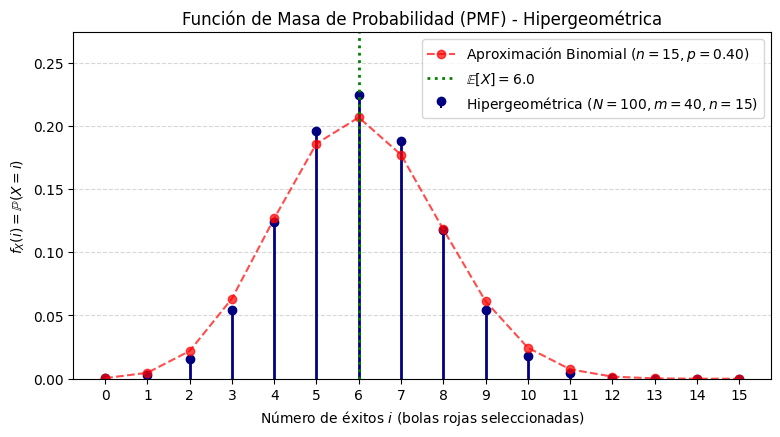

--- PROPIEDADES DE LA DISTRIBUCIÓN HIPERGEOMÉTRICA ---
• Esperanza E[X]: 6.0000
• Varianza Var(X): 3.0909


In [220]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import hypergeom, binom

N_poblacion = 100   # Tamaño total de la población (N)
m_éxitos = 40       # Número de elementos de interés / bolas rojas (m)
n_muestra = 15      # Tamaño de la muestra (n)

p_equivalente = m_éxitos / N_poblacion  # p = m / N

# i va desde max(0, n - (N - m)) hasta min(n, m)
i_min = int(np.maximum(0, n_muestra - (N_poblacion - m_éxitos)))
i_max = int(np.minimum(n_muestra, m_éxitos))
soporte = np.arange(i_min, i_max + 1)

# PMF Exacta Hipergeométrica: hypergeom.pmf(k, M=N, n=m, N=n)
pmf_hiper = hypergeom.pmf(soporte, N_poblacion, m_éxitos, n_muestra)

# PMF Aproximada Binomial: Bin(n, p)
pmf_binom = binom.pmf(soporte, n_muestra, p_equivalente)

plt.figure(figsize=(9, 4.5))

# Gráfica de bastones (stem plot) para la Hipergeométrica
markerline, stemlines, baseline = plt.stem(
    soporte, pmf_hiper, basefmt=" ", label=rf'Hipergeométrica $(N={N_poblacion}, m={m_éxitos}, n={n_muestra})$'
)
plt.setp(stemlines, color='navy', linewidth=2)
plt.setp(markerline, marker='o', color='navy', markersize=6)

# Línea punteada para la aproximación Binomial
plt.plot(soporte, pmf_binom, 'r--o', alpha=0.7, label=rf'Aproximación Binomial $(n={n_muestra}, p={p_equivalente:.2f})$')

# Esperanza matemática E[X] (Agregada la 'r' antes de la cadena)
esperanza = (n_muestra * m_éxitos) / N_poblacion
plt.axvline(esperanza, color='green', linestyle=':', linewidth=2, label=rf'$\mathbb{{E}}[X] = {esperanza:.1f}$')

plt.title('Función de Masa de Probabilidad (PMF) - Hipergeométrica')
plt.xlabel('Número de éxitos $i$ (bolas rojas seleccionadas)')
# Agregada la 'r' antes de la cadena para interpretar \mathbb sin warning
plt.ylabel(r'$f_X(i) = \mathbb{P}(X = i)$')
plt.xticks(soporte)
plt.ylim(0, pmf_hiper.max() + 0.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

var_hiper = n_muestra * p_equivalente * (1 - p_equivalente) * ((N_poblacion - n_muestra) / (N_poblacion - 1))

print("--- PROPIEDADES DE LA DISTRIBUCIÓN HIPERGEOMÉTRICA ---")
print(f"• Esperanza E[X]: {esperanza:.4f}")
print(f"• Varianza Var(X): {var_hiper:.4f}")

Ejercicio 5.Una compañía petrolera realiza un estudio geológico que indica que un pozo petrolero exploratorio debería tener un 20% de posibilidades de encontrar petróleo.

- ¿Cuál es la probabilidad de que el primer pozo se produzca en el tercer pozo perforado?

- ¿Cuál es la probabilidad de que el tercer pozo se produzca en el séptimo pozo perforado?

- ¿Cuál es la media y la varianza del número de pozos que se deben perforar si la compañía petrolera quiere establecer tres pozos productores?

Sea $p = 0.20$ la probabilidad de encontrar petróleo en un pozo exploratorio (éxito) y $q = 1 - p = 0.80$ la probabilidad de no encontrarlo (fracaso).


###  a) Probabilidad de que el primer pozo productor sea el tercero perforado

Sea $X$ el número de pozos perforados hasta obtener el **primer éxito**. La variable aleatoria $X$ sigue una distribución **Geométrica**: $X \sim \text{Geom}(p = 0.20)$.

Su función de masa de probabilidad es:
$$\mathbb{P}(X = x) = (1 - p)^{x - 1} p, \quad \text{para } x = 1, 2, 3, \dots$$

Sustituyendo para $x = 3$:
$$\mathbb{P}(X = 3) = (0.80)^{3 - 1} \cdot (0.20) = (0.80)^2 \cdot (0.20) = 0.64 \cdot 0.20 = 0.128$$

**Resultado:** La probabilidad es **$0.128$** (o $12.80\%$).

###  b) Probabilidad de que el tercer pozo productor sea el séptimo perforado

Sea $Y$ el número de pozos perforados hasta obtener el $r$-ésimo éxito. La variable aleatoria $Y$ sigue una distribución **Binomial Negativa**: $Y \sim \text{NB}(r = 3, p = 0.20)$.

Para que el **tercer pozo productor ($r = 3$)** sea el **séptimo perforado ($y = 7$)**, se requiere:
1. Obtener exactamente $r - 1 = 2$ pozos productores en los primeros $y - 1 = 6$ pozos perforados.
2. Que el $7^\circ$ pozo perforado sea un pozo productor.

Su función de masa de probabilidad es:
$$\mathbb{P}(Y = y) = \binom{y - 1}{r - 1} p^r (1 - p)^{y - r}$$

Sustituyendo $y = 7$ y $r = 3$:
$$\mathbb{P}(Y = 7) = \binom{6}{2} (0.20)^3 (0.80)^{7 - 3} = 15 \cdot (0.008) \cdot (0.80)^4$$

$$\mathbb{P}(Y = 7) = 15 \cdot 0.008 \cdot 0.4096 = 0.049152$$

**Resultado:** La probabilidad es **$0.049152$** (o aproximadamente $4.92\%$).

### c) Media y Varianza del número de pozos a perforar para obtener 3 pozos productores

Queremos hallar el valor esperado $\mathbb{E}[Y]$ y la varianza $\text{Var}(Y)$ de la variable $Y \sim \text{NB}(r = 3, p = 0.20)$.

### 1. Media (Esperanza Matemática):
$$\mathbb{E}[Y] = \frac{r}{p} = \frac{3}{0.20} = 15$$

**Interpretación:** En promedio, la compañía debe perforar **15 pozos** para establecer 3 pozos productores.

### 2. Varianza:
$$\text{Var}(Y) = \frac{r(1 - p)}{p^2} = \frac{3 \cdot 0.80}{(0.20)^2} = \frac{2.4}{0.04} = 60$$

**Resultado:**
* **Media ($\mu$):** $15$ pozos
* **Varianza ($\sigma^2$):** $60$ $\text{pozos}^2$ (Desviación estándar $\sigma \approx 7.75$ pozos)

# Variables aleatorias (absolutamente) continuas

**Definición.** Una variable aleatoria absolutamente continua es aquella para la cual existe una función $f_X$ no negativa, llamada función de densidad, tal que:
$$
F_X(x) = \mathbb{P}(X\leq x) = \int_{-\infty}^{x} f_X(y) dy, \quad x\in \mathbb{R}
$$

**Lema.** Sea $F_X$ una función de distribución. Supongamos que $F_X$ es derivable y que su derivada es continua en $(a, b)$, donde:
$ a = \inf \{ x \in \mathbb{R} \mid F_X(x) > 0 \}, \quad b = \sup \{ x \in \mathbb{R} \mid F_X(x) < 1 \}$
entonces, la función de densidad se puede obtener como:
$$ f_X(x) =
\begin{cases}
F'_X(x), & \text{si } x \in (a, b), \\
0, & \text{e.o.c.}
\end{cases}$$

Es decir,
$$ \frac{dF_X(x)}{dx} = f_X(x)$$


In [221]:
import numpy as np # Importamos Numpy
import numpy.random as npr # para generar numeros aleatorios

import scipy.stats as sps # Importamos el modulo SciPy
from scipy.stats import randint # para trabajar una uniforme discreta en un rango de enteros

import matplotlib.pyplot as plt #Visualizar datos

import random # para generar numeros aleatorios

## Variable aleatoria uniforme (rectangular) sobre el intervalo $(a,b)$.

Una variable aleatoria $X$ se dice que tiene distribución uniforme continua  en el intervalo $(a,b)$ con $a,b\in\mathbb{R}$, si su función de densidad esta dada por:
$$f_{X}(x)=\begin{cases}
	\frac{1}{b-a} &\quad \text{si } a< x < b\\
	\qquad 0 &\quad \text{en otro caso}  
\end{cases}$$

**Notación.** $X\sim \text{Unif}(a,b)$ $\text{Unif}[a,b]$

**Obs:**
* La distribución uniforme continua en $(a,b)$ es simétrica.
* A los intervalos de la misma longitud contenidos en $(a,b)$ se les asigna la misma probabilidad. Esto se representa gráficamente con la probabilidad de que $X$ se encuentre en el intervalo $(s,t)$:


La función de distribución de $X\sim Unif((a,b))$ esta dada por:
$$F_{X}(x)=\begin{cases}
	 0 &\quad \text{si } x\le a \\
	\frac{x-a}{b-a} &\quad \text{si } a<x<b\\
	 1 &\quad \text{si } x\ge b  
\end{cases}$$

La esperanza de una variable aleatoria uniforme es la siguiente,
$$\begin{align*}
\mathbb{E}[X] &= \int_{a}^{b}xf_{X}(x)dx = \int_{a}^{b}x\frac{1}{b-a}dx = \frac{1}{b-a}\int_{a}^{b}xdx  = \frac{1}{b-a}\left[\frac{x^{2}}{2}\right]_{a}^{b} \\ &= \frac{1}{b-a}\left[\frac{b^{2}}{2}-\frac{a^{2}}{2}\right] =  \frac{b^{2}-a^{2}}{2(b-a)} = \frac{(b-a)(b+a)}{2(b-a)} = \frac{a+b}{2}.
\end{align*}$$

Para calcular la varianza, primero vamos a calcular el segundo momento
$$\begin{align*}
\mathbb{E}[X^{2}] &= \int_{a}^{b}x^{2}f_{X}(x)dx = \int_{a}^{b}x^{2}\frac{1}{b-a}dx = \frac{1}{b-a}\int_{a}^{b}x^{2}dx \\ &= \frac{1}{b-a}\left[\frac{x^{3}}{3}\right]_{a}^{b} = \frac{1}{b-a}\left[\frac{b^{3}}{3}-\frac{a^{3}}{3}\right] =  \frac{b^{3}-a^{3}}{3(b-a)}.
\end{align*}$$

Por lo que se tiene lo siguiente

$$Var(X) = \mathbb{E}[X^{2}]-(\mathbb{E}[X])^{2} =\frac{b^{3}-a^{3}}{3(b-a)}-\left(\frac{a+b}{2}\right)^{2} = \frac{(b-a)^{2}}{12}.$$

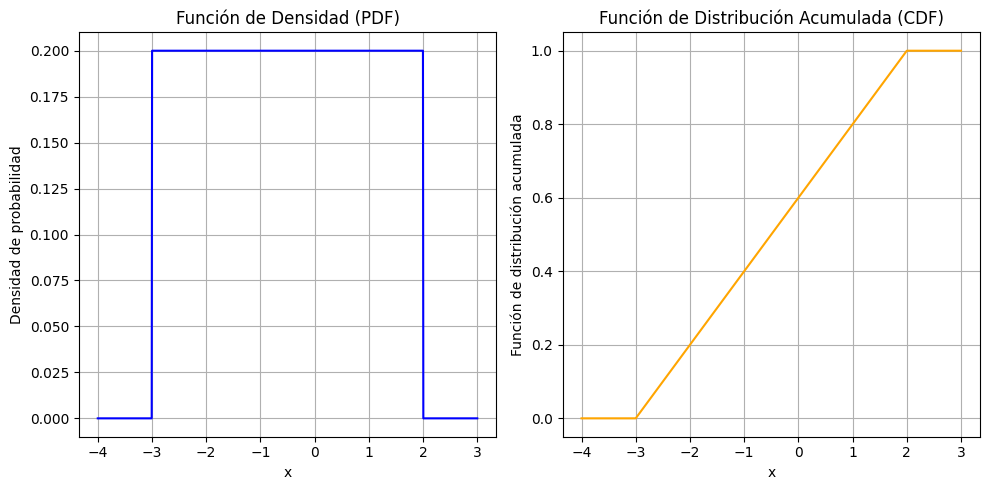

In [222]:
# Parámetros de la distribución uniforme
a = -3  # límite inferior
b = 2  # límite superior

# Definimos las funciones de densidad y distribución
# Función de densidad (pdf) de la distribución uniforme
def uniform_pdf(x, a, b):
    return np.where((x >= a) & (x <= b), 1 / (b - a), 0)

# Función de distribución (cdf) de la distribución uniforme
def uniform_cdf(x, a, b):
    return np.where(x < a, 0, np.where(x > b, 1, (x - a) / (b - a)))

# Generar valores de x
x = np.linspace(-4, 3, 1000)

# Calcular la función densidad
pdf_values = uniform_pdf(x, a, b)

# Calcular la función de distribución
cdf_values = uniform_cdf(x, a, b)

# Graficar la PDF
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(x, pdf_values, label='PDF', color='blue') # para cada gráfica
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.title('Función de Densidad (PDF)')
plt.grid(True)

# Graficar la CDF
plt.subplot(1, 2, 2)
plt.plot(x, cdf_values, label='CDF', color='orange')
plt.xlabel('x')
plt.ylabel('Función de distribución acumulada')
plt.title('Función de Distribución Acumulada (CDF)')
plt.grid(True)

plt.tight_layout()
plt.show()

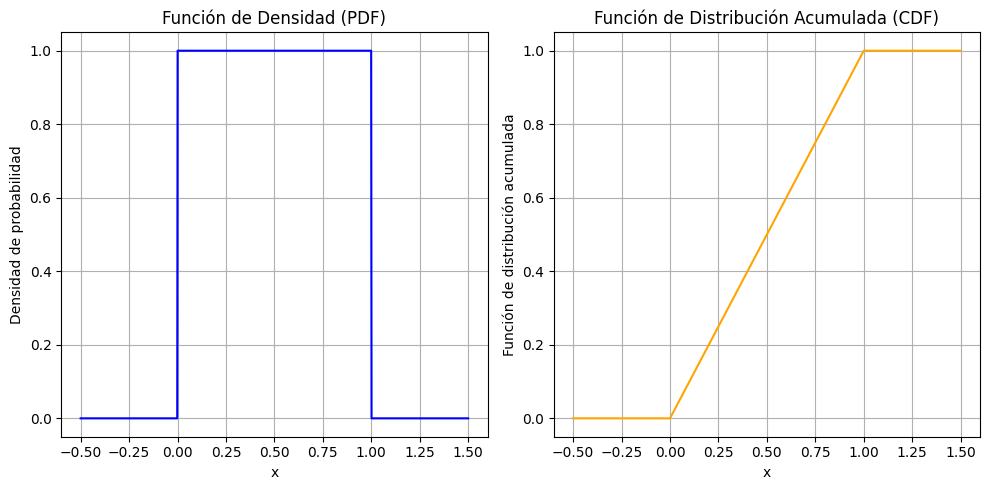

In [223]:
from scipy.stats import uniform

# Parámetros de la distribución uniforme
a = 0  # límite inferior
b = 1  # límite superior

# Crear el objeto de distribución uniforme usando scipy
uniform_dist = uniform(loc=a, scale=b-a)

# Generar valores de x
x = np.linspace(-0.5, 1.5, 1000)

# Calcular la PDF usando scipy
pdf_values = uniform_dist.pdf(x)

# Calcular la CDF usando scipy
cdf_values = uniform_dist.cdf(x)

# Graficar la PDF
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(x, pdf_values, label='PDF', color='blue')
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.title('Función de Densidad (PDF)')
plt.grid(True)

# Graficar la CDF
plt.subplot(1, 2, 2)
plt.plot(x, cdf_values, label='CDF', color='orange')
plt.xlabel('x')
plt.ylabel('Función de distribución acumulada')
plt.title('Función de Distribución Acumulada (CDF)')
plt.grid(True)

plt.tight_layout()
plt.show()

**Ejemplo.** 	Sea $X\sim Unif((-3,2))$. Vamos a calcular: $P(X\ge 0)$ y
$P(-5 \le X \le 1/2)$.

**Solución.** La función de densidad de esta variable aleatoria esta dada por:
$$f_{X}(x)=\begin{cases}
	\quad \frac{1}{5} &\quad \text{si } -3\le x \le 2\\
	\quad 0 &\quad \text{e.o.c}  
\end{cases}$$
Entonces,

$$\begin{align}
\mathbb{P}(X\ge 0) &= \int_{0}^{2}\frac{1}{5}dx=\frac{1}{5}x\Big|_{0}^{2}=\frac{2}{5} \\
\mathbb{P}(-5 \le X \le 1/2) &= \int_{-5}^{-3}f_{X}(x)dx+\int_{-3}^{1/2}\frac{1}{5}dx=\frac{1}{5}x\Big|_{-3}^{1/2}=\frac{1}{5}\left(\frac{1}{2}+3\right)=\frac{7}{10}
\end{align}$$

Utilizando la $F_X$,
$$F_X(x):=\mathbb{P}(X\le x)$$
se tiene:

- $\mathbb{P}(X\ge 0)=1-F_X(0)$
- $\mathbb{P}(-5\le X \le 1/2) = F_{X}(1/2)-F_{X}(-5)$

In [224]:
from scipy.stats import uniform

# Parámetros de la distribución uniforme
a = -3  # límite inferior
b = 2   # límite superior

# Crear el objeto de distribución uniforme usando scipy
uniform_dist = uniform(loc=a, scale=b-a)

# Calcular P(X >= 0) = 1 - P(X < 0)
p_0 = 1 - uniform_dist.cdf(0)

# Calcular P(-5 <= X <= 1/2)
p_interval = uniform_dist.cdf(1/2) - uniform_dist.cdf(-5)

# Imprimir los resultados
print(f"P(X >= 0) = {p_0}")
print(f"P(-5 <= X <= 1/2) = {p_interval}")

P(X >= 0) = 0.4
P(-5 <= X <= 1/2) = 0.7


Ejercicio. Un alumno se dirige a la biblioteca para solicitar el préstamo de un libro y decide que no puede esperar más de $10$ minutos en ser atendido. Supongamos que el bibliotecario tarda por lo menos $0.5$ minutos en atender a una persona, entonces es razonable proponer una distribución uniforme en el intervalo $[0.5,10]$ para modelar el comportamiento de la variable $X$ que es el tiempo en ser atendido (en  minutos).

- Da la función de densidad y gráfica.
- ¿Cuál es la probabilidad de que el tiempo en ser atendido sea mayor a $5$ minutos pero menor a $8$ minutos?
- ¿Cuál es la esperanza y varianza?
- Calcula la función de distribución y gráficala, y con ella calcula: $\mathbb{P}(2.51\le X \le 7.99)$.

La variable aleatoria $X$, que representa el tiempo de atención en minutos, sigue una distribución uniforme continua en el intervalo $[a, b] = [0.5, 10]$:$$X \sim U(0.5, 10)$$ Función de densidad $f(x)$ y gráficaDesarrollo analíticoLa función de densidad de probabilidad (PDF) para una variable uniforme continua en $[a,b]$ está dada por:$$f(x) = \begin{cases} \frac{1}{b - a} & \text{si } a \le x \le b \\ 0 & \text{en otro caso} \end{cases}$$Sustituyendo $a = 0.5$ y $b = 10$:$$b - a = 10 - 0.5 = 9.5$$$$f(x) = \begin{cases} \frac{1}{9.5} = \frac{2}{19} \approx 0.10526 & \text{si } 0.5 \le x \le 10 \\ 0 & \text{en otro caso} \end{cases}$$ Probabilidad $P(5 < X < 8)$Desarrollo analíticoPara calcular la probabilidad dentro de un intervalo en una distribución uniforme continua:$$P(c < X < d) = \frac{d - c}{b - a}$$Sustituyendo $c = 5$ y $d = 8$:$$P(5 < X < 8) = \frac{8 - 5}{10 - 0.5} = \frac{3}{9.5} = \frac{6}{19} \approx 0.3158 \quad (31.58\%)$$ Esperanza $E[X]$ y Varianza $V[X]$Esperanza (Media)$$E[X] = \frac{a + b}{2} = \frac{0.5 + 10}{2} = \frac{10.5}{2} = 5.25 \text{ minutos}$$Varianza$$V[X] = \frac{(b - a)^2}{12} = \frac{(9.5)^2}{12} = \frac{90.25}{12} \approx 7.5208 \text{ min}^2$$ Función de distribución $F(x)$ y cálculo de $P(2.51 \le X \le 7.99)$Desarrollo analíticoLa función de distribución acumulada (CDF) es:$$F(x) = \begin{cases} 0 & \text{si } x < 0.5 \\ \frac{x - 0.5}{9.5} & \text{si } 0.5 \le x \le 10 \\ 1 & \text{si } x > 10 \end{cases}$$Cálculo utilizando $F(x)$:Por propiedades de la CDF, $P(c \le X \le d) = F(d) - F(c)$:Evaluamos en $d = 7.99$:$$F(7.99) = \frac{7.99 - 0.5}{9.5} = \frac{7.49}{9.5} \approx 0.78842$$Evaluamos en $c = 2.51$:$$F(2.51) = \frac{2.51 - 0.5}{9.5} = \frac{2.01}{9.5} \approx 0.21158$$Restamos los valores:$$P(2.51 \le X \le 7.99) = F(7.99) - F(2.51) = 0.78842 - 0.21158 = 0.57684 \quad (57.68\%)$$(De forma alternativa: $\frac{7.99 - 2.51}{9.5} = \frac{5.48}{9.5} \approx 0.57684$)

Esperanza E[X]: 5.2500 minutos
Varianza V[X]: 7.5208 min^2
P(5 < X < 8): 0.3158 (31.58%)
P(2.51 <= X <= 7.99): 0.5768 (57.68%)


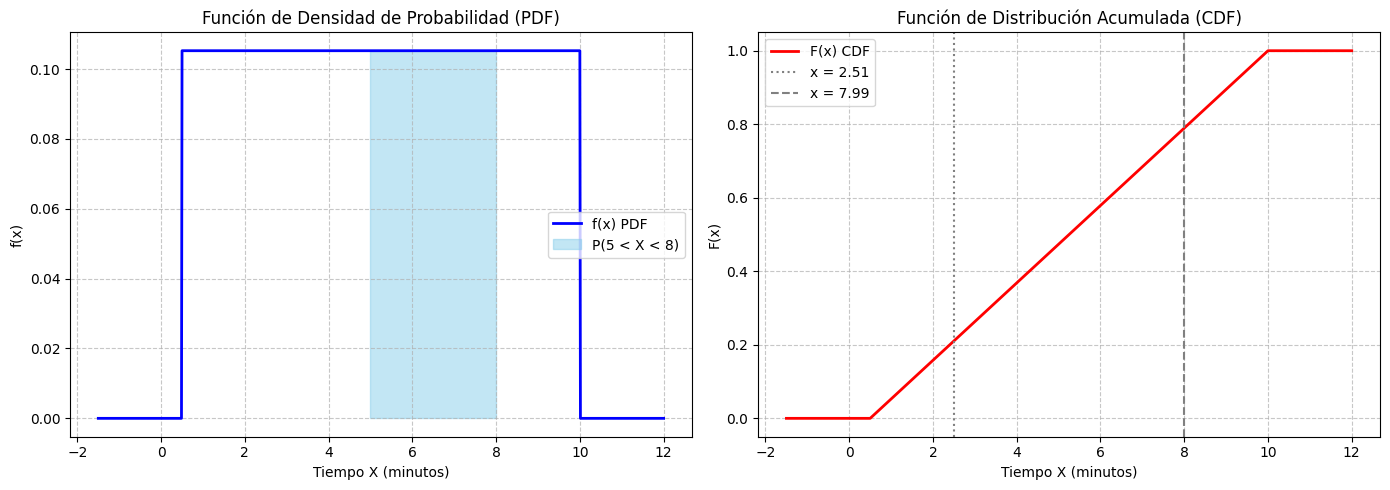

In [225]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# Parámetros del problema
a, b = 0.5, 10
loc = a
scale = b - a  # Ancho del intervalo (9.5)

dist_uniforme = uniform(loc=loc, scale=scale)

esperanza = dist_uniforme.mean()
varianza = dist_uniforme.var()

print(f"Esperanza E[X]: {esperanza:.4f} minutos")
print(f"Varianza V[X]: {varianza:.4f} min^2")

p_5_8 = dist_uniforme.cdf(8) - dist_uniforme.cdf(5)
p_rango = dist_uniforme.cdf(7.99) - dist_uniforme.cdf(2.51)

print(f"P(5 < X < 8): {p_5_8:.4f} ({p_5_8*100:.2f}%)")
print(f"P(2.51 <= X <= 7.99): {p_rango:.4f} ({p_rango*100:.2f}%)")

x = np.linspace(a - 2, b + 2, 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(x, dist_uniforme.pdf(x), 'b-', lw=2, label='f(x) PDF')
ax1.fill_between(x, dist_uniforme.pdf(x), where=(x >= 5) & (x <= 8), color='skyblue', alpha=0.5, label='P(5 < X < 8)')
ax1.set_title('Función de Densidad de Probabilidad (PDF)')
ax1.set_xlabel('Tiempo X (minutos)')
ax1.set_ylabel('f(x)')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()


ax2.plot(x, dist_uniforme.cdf(x), 'r-', lw=2, label='F(x) CDF')
ax2.axvline(2.51, color='gray', linestyle=':', label='x = 2.51')
ax2.axvline(7.99, color='gray', linestyle='--', label='x = 7.99')
ax2.set_title('Función de Distribución Acumulada (CDF)')
ax2.set_xlabel('Tiempo X (minutos)')
ax2.set_ylabel('F(x)')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

In [226]:
import numpy as np # Importamos Numpy
import numpy.random as npr # para generar numeros aleatorios

import scipy.stats as sps # Importamos el modulo SciPy
from scipy.stats import randint # para trabajar una uniforme discreta en un rango de enteros

import matplotlib.pyplot as plt #Visualizar datos

import random # para generar numeros aleatorios

# Variable aleatoria exponencial con parámetro $\lambda >0$

La distribución exponencial es una de las distribuciones continuas más utilizadas. A menudo se utiliza para modelar el tiempo transcurrido entre eventos.

Algunos ejemplos en los que podría utilizarse la distribución exponencial son:
* El tiempo transcurrido en un call center hasta recibir la primera llamada del día.
* El tiempo entre terremotos de una determinada magnitud.
* La cantidad de metros de alambre que produce una máquina hasta encontrar una falla en el alambre.

Se dice que la variable aleatoria $X$ tiene distribución exponencial de parámetro $\lambda>0$ si su función de densidad está dada por:
$$f_{X}(x)=\begin{cases}
\lambda e^{-\lambda x} & x>0\\
0 & \text{en otro caso}
\end{cases}$$

La esperanza y varianza son:
$$\mathbb{E}[X]= \frac{1}{\lambda}, \qquad Var(X)=\frac{1}{\lambda^2}$$

Notación. $X\sim Exp(\lambda).$

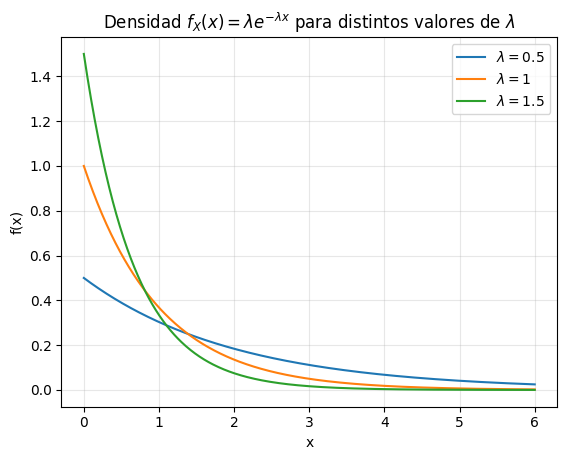

In [227]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 6, 500)
lambdas = [0.5, 1, 1.5]

for lam in lambdas:
    plt.plot(x, lam*np.exp(-lam*x), label=fr'$\lambda={lam}$')

plt.title(r'Densidad $f_X(x)=\lambda e^{-\lambda x}$ para distintos valores de $\lambda$')
plt.xlabel('x'); plt.ylabel('f(x)'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Función de distribución (CDF)

Por definición, $F_X(x) = \mathbb{P}(X\le x) = \displaystyle\int_{-\infty}^{x} f_X(t)\,dt$. Para $X\sim Exp(\lambda)$ y $x>0$:

$$F_X(x) = \int_0^x \lambda e^{-\lambda t}\,dt = \left[-e^{-\lambda t}\right]_0^x = -e^{-\lambda x}-(-e^{0}) = 1-e^{-\lambda x}$$

Por lo tanto:

$$F_{X}(x)=\begin{cases}
1-e^{-\lambda x} & x\ge 0\\
0 & x<0
\end{cases}$$

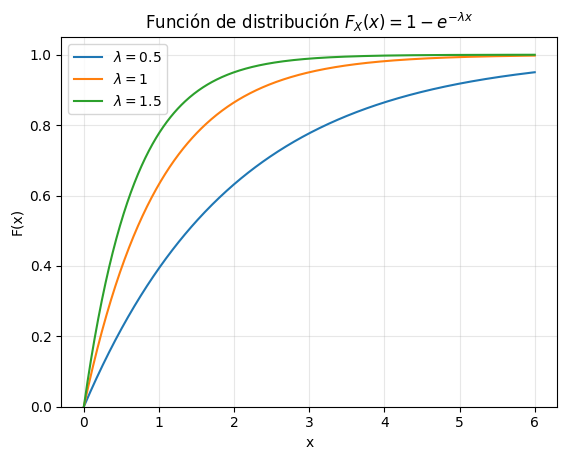

In [228]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 6, 500)
lambdas = [0.5, 1, 1.5]

for lam in lambdas:
    plt.plot(x, 1 - np.exp(-lam*x), label=fr'$\lambda={lam}$')

plt.title(r'Función de distribución $F_X(x)=1-e^{-\lambda x}$')
plt.xlabel('x'); plt.ylabel('F(x)'); plt.ylim(0, 1.05); plt.legend(); plt.grid(alpha=0.3)
plt.show()

De aquí se obtiene también la **función de supervivencia** (la cola de la distribución):
$$\mathbb{P}(X>x) = 1-F_X(x) = e^{-\lambda x}$$

$\textbf{Propiedad de pérdida de memoria:}$
$$\mathbb{P}(X>t+s \mid X>t)=\mathbb{P}(X>s)=e^{-\lambda s}.$$

**¿Qué significa?** Si ya sabemos que el evento no ha ocurrido después de un tiempo $t$ (por ejemplo, un foco ya duró $t$ horas sin fallar), la probabilidad de esperar $s$ unidades de tiempo **más** es la misma que la probabilidad de esperar $s$ unidades desde el inicio. El proceso "no recuerda" cuánto tiempo ya transcurrió.

**Observación (parametrización alternativa).** A veces escriben la densidad exponencial en términos de su **media** $\mu = \dfrac{1}{\lambda}$ en lugar de la tasa $\lambda$:
$$f_{X}(x)=\begin{cases}
\dfrac{1}{\mu} e^{-x/\mu} & x>0\\[4pt]
0 & \text{en otro caso}
\end{cases}$$
Con esta parametrización:
$$\mathbb{E}[X]= \int_{0}^{\infty}x\, f_{X}(x)\,dx = \int_{0}^{\infty}x\,\frac{1}{\mu}e^{-x/\mu}\,dx = \mu$$
$$\text{Var}(X) = \mathbb{E}[X^{2}]-(\mathbb{E}[X])^{2} = \int_{0}^{\infty}x^{2}\frac{1}{\mu}e^{-x/\mu}dx - \mu^{2} = 2\mu^2-\mu^2= \mu^{2}$$
Es **la misma** distribución de arriba; solo cambia el nombre del parámetro ($\mu = 1/\lambda$).

## Ejemplo

Consideremos la variable aleatoria $X$ como el tiempo (en minutos) entre la llegada de dos personas a la fila de una sucursal bancaria.

Adicionalmente, el banco ha determinado que solo el $10\%$ de las veces el tiempo que transcurre entre la llegada de una persona y otra es mayor a dos minutos.

Esto permite calcular el valor de $\lambda$, ya que
$$\mathbb{P}(X>2)=0.1$$
entonces
$$1-\mathbb{P}(X\le 2) = 1-F_{X}(2) = 0.1$$

Notemos que si $X\sim Exp(\lambda)$, entonces $F_{X}(x) = 1-e^{-\lambda x}$.

Por lo que $F_{X}(2)= 1-e^{-2\lambda} =0.9$, entonces $e^{-2\lambda}=0.1$. Por lo tanto
$$-2\lambda=\ln(0.1) \;\Rightarrow\; \lambda=\frac{-\ln(0.1)}{2}\approx 1.15$$

Por lo tanto $X\sim Exp(1.15)$. (Equivalentemente, el tiempo *promedio* entre llegadas es $1/\lambda \approx 0.87$ minutos — ese $0.87$ es la media, no $\lambda$.)

Ahora queremos calcular la probabilidad de que entre la llegada de una persona y otra transcurra por lo menos un minuto, lo cual puede calcularse de dos formas:

$$\mathbb{P}(X>1) = \int_{1}^{\infty}f_{X}(x)\,dx = \int_{1}^{\infty}1.15\,e^{-1.15x}\,dx = e^{-1.15}\approx 0.32$$

$$\mathbb{P}(X>1) = 1-\mathbb{P}(X\le 1) = 1-F_X(1) = 1-\left(1-e^{-1.15}\right)=e^{-1.15}\approx 0.32$$

Ambos métodos coinciden, como debe ser.


In [229]:
import numpy as np
from scipy.stats import expon

# lambda obtenido a partir de P(X>2) = 0.1
lam = -np.log(0.1) / 2
print("lambda =", round(lam, 4))

rv = expon(scale=1/lam)  # scale = 1/lambda, NO lambda
print("P(X>1) =", round(rv.sf(1), 4))   # sf es la funcion de supervivencia

lambda = 1.1513
P(X>1) = 0.3162


# Ejercicios Adicionales: Distribución Exponencial

---

## Ejercicio 1

El tiempo (en minutos) entre llegadas de clientes a una caja registradora se modela como $X \sim \text{Exp}(\lambda)$, con un tiempo promedio entre llegadas de $3$ minutos.

* $E[X] = \frac{1}{\lambda} = 3$
* **Función de densidad (PDF):** $f(x) = \lambda e^{-\lambda x}$ para $x \ge 0$
* **Función de distribución acumulada (CDF):** $F(x) = 1 - e^{-\lambda x}$ para $x \ge 0$

### a) Encuentra $\lambda$.

Como la media de una variable exponencial es $E[X] = \frac{1}{\lambda}$:

$$\frac{1}{\lambda} = 3 \implies \lambda = \frac{1}{3} \approx 0.3333 \text{ clientes/minuto}$$

### b) Calcula $P(X < 2)$.

Usamos la función de distribución acumulada $F(2)$:

$$P(X < 2) = F(2) = 1 - e^{-\frac{1}{3}(2)} = 1 - e^{-\frac{2}{3}} \approx 1 - 0.5134 = 0.4866 \quad (48.66\%)$$


### c) Calcula $P(X > 4)$.

Por la propiedad de la cola de la distribución exponencial, $P(X > x) = e^{-\lambda x}$:

$$P(X > 4) = e^{-\frac{1}{3}(4)} = e^{-\frac{4}{3}} \approx 0.2636 \quad (26.36\%)$$


### d) Calcula $P(2 < X < 6)$.

Restamos las probabilidades acumuladas $F(6) - F(2)$:

$$P(2 < X < 6) = F(6) - F(2) = \left(1 - e^{-\frac{6}{3}}\right) - \left(1 - e^{-\frac{2}{3}}\right) = e^{-\frac{2}{3}} - e^{-2}$$

$$P(2 < X < 6) = 0.5134 - 0.1353 = 0.3781 \quad (37.81\%)$$

---

## Ejercicio 2 (Pérdida de memoria)

La duración de un foco (en horas) es $X \sim \text{Exp}(\lambda)$ con duración promedio de $1000$ horas. Si el foco ya ha funcionado $500$ horas sin fallar, ¿cuál es la probabilidad de que dure al menos $500$ horas más? Resuelve usando la propiedad de pérdida de memoria y comprueba que coincide con $P(X > 500)$ calculada "desde cero".

* $E[X] = \frac{1}{\lambda} = 1000 \implies \lambda = \frac{1}{1000} = 0.001 \text{ fallas/hora}$


1. Usando la propiedad de pérdida de memoria:

La propiedad de pérdida de memoria establece que para cualquier $t, s \ge 0$:
$$P(X > t + s \mid X > t) = P(X > s)$$

En este caso, queremos saber la probabilidad de que dure más de $500 + 500 = 1000$ horas dado que ya duró $t = 500$ horas:
$$P(X > 500 + 500 \mid X > 500) = P(X > 500)$$

Calculando $P(X > 500)$:
$$P(X > 500) = e^{-\lambda(500)} = e^{-\frac{500}{1000}} = e^{-0.5} \approx 0.6065 \quad (60.65\%)$$


2. Calculando "desde cero" con probabilidad condicional:

Por definición de probabilidad condicional:
$$P(X > 1000 \mid X > 500) = \frac{P(X > 1000 \cap X > 500)}{P(X > 500)} = \frac{P(X > 1000)}{P(X > 500)}$$

Calculamos cada probabilidad de la cola:
* $P(X > 1000) = e^{-\frac{1000}{1000}} = e^{-1}$
* $P(X > 500) = e^{-\frac{500}{1000}} = e^{-0.5}$

Sustituimos en la fórmula:
$$P(X > 1000 \mid X > 500) = \frac{e^{-1}}{e^{-0.5}} = e^{-1 - (-0.5)} = e^{-0.5} \approx 0.6065 \quad (60.65\%)$$

> **Conclusión:** Se comprueba que ambas formas dan exactamente el mismo resultado ($e^{-0.5} \approx 0.6065$).

---

## Ejercicio 3 (Proceso de Poisson)

Los terremotos de magnitud $\ge 5$ en una región ocurren, en promedio, $2$ veces al año, y el tiempo entre ellos se modela como exponencial. ¿Cuál es la probabilidad de que el próximo terremoto de esa magnitud ocurra dentro de los siguientes $3$ meses?

* **Tasa anual:** $\lambda = 2 \text{ terremotos/año}$
* **Tiempo en años:** $3 \text{ meses} \implies t = \frac{3}{12} = 0.25 \text{ años}$

Sea $T \sim \text{Exp}(\lambda = 2)$ el tiempo transcurrido (en años) hasta el próximo terremoto.


Queremos hallar $P(T \le 0.25)$:

$$P(T \le 0.25) = F(0.25) = 1 - e^{-\lambda t}$$

Sustituyendo $\lambda = 2$ y $t = 0.25$:

$$P(T \le 0.25) = 1 - e^{-(2 \cdot 0.25)} = 1 - e^{-0.5}$$

$$P(T \le 0.25) \approx 1 - 0.6065 = 0.3935 \quad (39.35\%)$$

Ejercicio 2. Calcular las probabilidades con Scipy



A continuación se implementa la solución computacional de los ejercicios planteados usando las funciones:
* `pmf(k)` / `pdf(x)`: Función de masa/densidad de probabilidad $\mathbb{P}(X = x)$
* `cdf(x)`: Función de distribución acumulada $\mathbb{P}(X \le x)$
* `ppf(q)`: Función percentil (inversa de la CDF) para hallar valores $c$ tales que $\mathbb{P}(X \le c) = q$

In [230]:
import numpy as np
from scipy import stats

print("="*60)
print("     CÁLCULO DE PROBABILIDADES CON SCIPY.STATS")
print("="*60)

# ------------------------------------------------------------------------------
# EJERCICIO 1: Rifa de Boletos (Uniforme Discreta en {1, 2, ..., 100})
# ------------------------------------------------------------------------------
print("\n1. VARIABLE UNIFORME DISCRETA (Rifa de 100 boletos)")
# P(X > 80) = 1 - P(X <= 80)
p_unif_gt_80 = 1 - stats.randint.cdf(80, low=1, high=101)
print(f"   • P(X > 80) = {p_unif_gt_80:.4f}")

# ------------------------------------------------------------------------------
# EJERCICIO 2: Cuentas Incobrables (Binomial: n=6, p=0.05)
# ------------------------------------------------------------------------------
print("\n2. DISTRIBUCIÓN BINOMIAL (Cuentas incobrables)")
n_bin, p_bin = 6, 0.05

# P(X = 3)
p_bin_eq_3 = stats.binom.pmf(3, n_bin, p_bin)

# P(X >= 1) = 1 - P(X = 0)
p_bin_gte_1 = 1 - stats.binom.cdf(0, n_bin, p_bin)

print(f"   • P(X = 3)  = {p_bin_eq_3:.6f}")
print(f"   • P(X >= 1) = {p_bin_gte_1:.6f}")

# ------------------------------------------------------------------------------
# EJERCICIO 3: Accidentes en Intersección (Poisson: lambda=2)
# ------------------------------------------------------------------------------
print("\n3. DISTRIBUCIÓN POISSON (Accidentes)")
lam_poi = 2

# P(X > 2) = 1 - P(X <= 2)
p_poi_gt_2 = 1 - stats.poisson.cdf(2, lam_poi)

# P(X > 2 | X >= 1) = P(X > 2) / P(X >= 1)
p_poi_gte_1 = 1 - stats.poisson.cdf(0, lam_poi)
p_poi_cond = p_poi_gt_2 / p_poi_gte_1

print(f"   • P(X > 2)          = {p_poi_gt_2:.4f}")
print(f"   • P(X > 2 | X >= 1) = {p_poi_cond:.4f}")

# ------------------------------------------------------------------------------
# EJERCICIO 4: Variable Gaussiana (Normal: mu=2.4, sigma^2=1.6)
# ------------------------------------------------------------------------------
print("\n4. DISTRIBUCIÓN NORMAL (X ~ N(2.4, 1.6))")
mu_norm = 2.4
sigma_norm = np.sqrt(1.6) # scipy requiere la desviación estándar sigma

# P(2 < X < 3) = F(3) - F(2)
p_norm_range = stats.norm.cdf(3, mu_norm, sigma_norm) - stats.norm.cdf(2, mu_norm, sigma_norm)

# P(X > 1.5) = 1 - F(1.5)
p_norm_gt_1_5 = 1 - stats.norm.cdf(1.5, mu_norm, sigma_norm)

print(f"   • P(2 < X < 3) = {p_norm_range:.4f}")
print(f"   • P(X > 1.5)   = {p_norm_gt_1_5:.4f}")

# Cálculo Inverso: Hallar 'c' tal que P(X > c) = 0.10  => P(X <= c) = 0.90 para N(12, 4)
c_val = stats.norm.ppf(0.90, loc=12, scale=2)
print(f"   • Valor 'c' tal que P(X > c) = 0.10 para N(12, 4): c = {c_val:.4f}")

# ------------------------------------------------------------------------------
# EJERCICIO 5: Call Center (Gamma: alpha=10, beta=1/3 -> scale=3)
# ------------------------------------------------------------------------------
print("\n5. DISTRIBUCIÓN GAMMA (Tiempo en Call Center)")
alpha_g = 10
scale_g = 3 # scale = 1/beta

# P(X > 30) = 1 - F(30)
p_gamma_gt_30 = 1 - stats.gamma.cdf(30, a=alpha_g, scale=scale_g)
print(f"   • P(X > 30 min) = {p_gamma_gt_30:.4f}")

# ------------------------------------------------------------------------------
# EJERCICIO 6: Ventas de Gasolina (Beta: a=4, b=2)
# ------------------------------------------------------------------------------
print("\n6. DISTRIBUCIÓN BETA (Proporción de ventas de gasolina)")
a_beta, b_beta = 4, 2

# P(X > 0.9) = 1 - F(0.9)
p_beta_gt_09 = 1 - stats.beta.cdf(0.9, a=a_beta, b=b_beta)
print(f"   • P(X > 0.90) = {p_beta_gt_09:.4f}")
print("="*60)

     CÁLCULO DE PROBABILIDADES CON SCIPY.STATS

1. VARIABLE UNIFORME DISCRETA (Rifa de 100 boletos)
   • P(X > 80) = 0.2000

2. DISTRIBUCIÓN BINOMIAL (Cuentas incobrables)
   • P(X = 3)  = 0.002143
   • P(X >= 1) = 0.264908

3. DISTRIBUCIÓN POISSON (Accidentes)
   • P(X > 2)          = 0.3233
   • P(X > 2 | X >= 1) = 0.3739

4. DISTRIBUCIÓN NORMAL (X ~ N(2.4, 1.6))
   • P(2 < X < 3) = 0.3065
   • P(X > 1.5)   = 0.7616
   • Valor 'c' tal que P(X > c) = 0.10 para N(12, 4): c = 14.5631

5. DISTRIBUCIÓN GAMMA (Tiempo en Call Center)
   • P(X > 30 min) = 0.4579

6. DISTRIBUCIÓN BETA (Proporción de ventas de gasolina)
   • P(X > 0.90) = 0.0815


# Variable aleatoria normal con parámetros media $\mu$ y varianza $\sigma^{2}$.

La distribución normal es una de las más importantes y de mayor uso tanto en la teoría de la probabilidad, como en la teoría estadística.

También llamada distribución gaussiana, en honor a Gauss, a quien se considera el padre de ésta distribución.

La importancia de la distribución normal, radica en el famoso Teorema central del límite. Fue descubierta por De Moivre en 1733 como un límite de la distribución binomial.


La importancia de esta distribución radica en que permite modelar numerosos fenómenos naturales, sociales y psicológicos, por ejemplo:
* Estatura
* Efectos de un fármaco
* Consumo de cierto producto por un grupo de individuos
* Coeficiente intelectual
* Nivel de ruido en telecomunicaciones
* Errores cometidos al medir ciertas magnitudes

Además, esta distribución juega un papel de suma importancia en la inferencia estadística.

Se dice que la variable aleatoria $X$ tiene distribución normal de parámetros $\mu$ y $\sigma^{2}$, donde $\mu,\sigma\in\mathbb{R}$ y $\sigma>0$, si su función de densidad está dada por:
$$f_{X}(x)=\begin{cases}
	\frac{1}{\sqrt{2\pi\sigma^{2}}}e^{-\frac{(x-\mu)^{2}}{2\sigma^{2}}} &\quad \text{si }  x \in\mathbb{R} \\
	\qquad 0 &\quad \text{e.o.c}  
\end{cases}$$

**Notación.** $X\sim N(\mu,\sigma^{2})$


Tal curva (**la campana de Gauss-Bell**) es una función que depende de los parámetros $\mu$ y $\sigma^{2}$.


**Observación:** El parámetro $\mu$ se llama *media* y el  parámetro $\sigma^{2}$ se llama *varianza*.

La función de densidad definida anteriormente es efecto función de densidad, ya que
$$\int_{\mathbb{R}}f_{X}(x)dx = \int_{\mathbb{R}}\frac{1}{\sqrt{2\pi\sigma^{2}}}e^{-\frac{(x-m)^{2}}{2\sigma^{2}}}  = 1 $$

Variable aleatoria normal con parámetros  0  y  1 .
La ley de $Z\sim N(0,1)$ está dada por la función de densidad
$$
f_{Z}(z) = \frac{1}{\sqrt{2\pi}}e^{-\frac{z^2}{2}},
$$
para $z\in \mathbb{R}$.

Sabemos que:
* La varianza es usada como una medida para comparar la dispersión en dos o más conjuntos de observaciones.
* Una desviación estándar pequeña indica que los valores de la variable aleatoria se encuentran cercanos a la media.
* Una desviación estándar grande indica que los valores de la variable aleatoria se dispersan mucho con respecto a la media.

La función de distribución de una variable aleatoria $X\sim N(\mu,\sigma^{2})$ está dada por:
$$F_{X}(x) = \int_{-\infty}^{x}\frac{1}{\sqrt{2\pi\sigma^{2}}}e^{-\frac{(y-\mu)^{2}}{2\sigma^{2}}}dy$$

Esta nos proporciona la probabilidad de que $X$ tome calores menores o iguales a un valor específico $x$, y corresponde al área bajo la curva en el intervalo $(-\infty,x]$:

No es sencillo calcular $F_{X}(x)$, pero cualquier v.a. gaussiana puede transformarse a una v.a. estandarizada. Existen tablas para esta v.a., lo cual hace los cálculos más fáciles.

**Proposición**  Sea $X\sim N(\mu,\sigma^{2})$, entonces
$$Z=\frac{X-\mu}{\sigma}$$
tiene una distribución gaussiana con media $0$ y varianza $1$, es decir, $Z\sim N(0,1)$.


**Demostración** 	Primero vamos a calcular la función de distribución de $Z$:
$$F_{Z}(z):=\mathbb{P}(Z\le z) = \mathbb{P}\left(\frac{X-\mu}{\sigma}\le z\right) = \mathbb{P}(X\le \sigma z + \mu) := F_{X}(\sigma z + \mu)$$
Entonces, la función de densidad de $Z$ esta dada por:
$$f_{Z}(z) = \frac{dF_{Z}(z)}{dz} = \frac{dF_{X}(\sigma z + \mu)}{dz} = \sigma f_{X}(\mu+\sigma z) = \frac{e^{-z^{2}/2}}{\sqrt{2\pi}}$$

Decimos que $X$ tiene distribución gaussiana estándar (normal estándar), $X\sim N(0,1)$, si su función de densidad esta dada por:
$$f_{X}(x)=\begin{cases}
	\frac{e^{-x^{2}/2}}{\sqrt{2\pi}} &\quad \text{si }  x \in\mathbb{R} \\
	\quad 0 &\quad \text{e.o.c}  
\end{cases}$$

Podemos calcular cualquier probabilidad de la forma
$$\mathbb{P}(a<X<b)$$
de la siguiente manera: para $z\ge 0$, definimos
$$\Phi(z) = \frac{1}{\sqrt{2\pi}}\int_{0}^{z}e^{-x^{2}/2}dx.$$


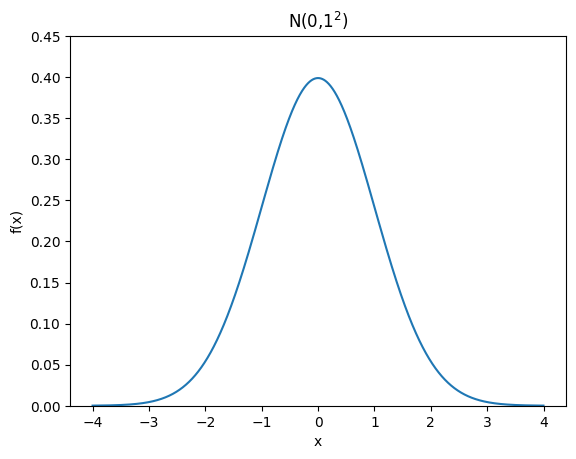

In [231]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
fig, ax = plt.subplots()
x= np.arange(-4,4,0.001) #generar valores de x
ax.set_title('N(0,$1^2$)')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.plot(x, norm.pdf(x))
ax.set_ylim(0,0.45)
plt.show()

Propiedades de la función de densidad de probabilidades de una distribución normal estándar:

1. Es positiva: $f(x)\geq 0$ para todo $x$ real.
2. Es continua y derivable en todas partes.
3. Es simétrica alrededor de $\mu$.
4. Conforme $x$ toma valores muy grandes de manera positiva y negativa, la función decrece hacia cero muy rápidamente.
5. Tiene un máximo global.
6. El área total bajo la curva es igual a $1$.

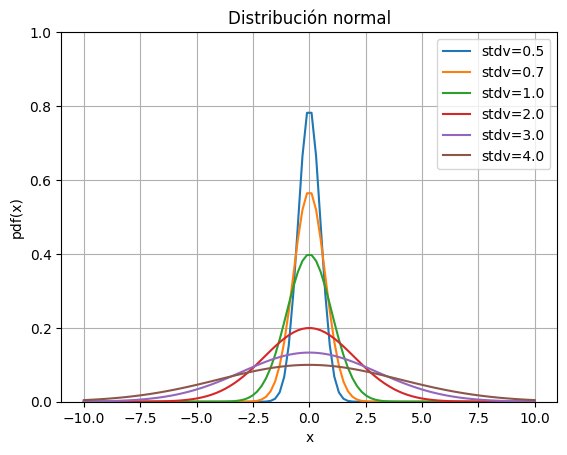

In [232]:
from scipy.stats import norm
fig, ax = plt.subplots()
x = np.linspace(-10,10,100)
stdvs = [0.5, 0.7, 1.0, 2.0, 3.0, 4.0]
for s in stdvs:
    ax.plot(x, norm.pdf(x,scale=s), label='stdv=%.1f' % s)

ax.set_xlabel('x')
ax.set_ylabel('pdf(x)')
ax.set_title('Distribución normal')
ax.legend(loc='best', frameon=True)
ax.set_ylim(0,1)
ax.grid(True)

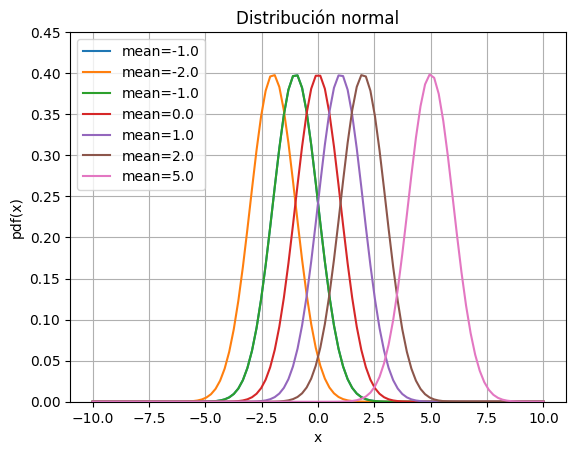

In [233]:
from scipy.stats import norm
fig, ax = plt.subplots()
x = np.linspace(-10,10,100)
means = [-1.0,-2.0, -1.0, 0.0, 1.0, 2.0, 5.0]
for mean in means:
    ax.plot(x, norm.pdf(x,loc=mean), label='mean=%.1f' % mean)

ax.set_xlabel('x')
ax.set_ylabel('pdf(x)')
ax.set_title('Distribución normal')
ax.legend(loc='best', frameon=True)
ax.set_ylim(0,0.45)
ax.grid(True)

### Función de distribución acumulativa de una normal $N(\mu,\sigma^2)$.

Gracias a las propiedades anteriores, es posible calcular áreas delimitadas de la función $f$. Si $a$ y $b$ son reales cualesquiera, denotaremos por
$$P(a\leq X\leq b),$$
la probabilidad de que $X$ esté en el intervalo $[a,b]$, al área bajo la curva de $f(x)$ sobre el intervalo $[a,b]$.

También, $P(X\leq x)$ denotara al área bajo la curva de la función $f(x)$ sobre el intervalo $(-\infty,x)$ y $P(X>x)$ denotara al área bajo la curva de la función $f(x)$ sobre el intervalo $(x, \infty)$.

A la probabilidad $\text{cdf}(x):=P(X\leq x)$ se llama la distribución acumulativa (hasta el valor $x$) de $f(x)$.

Con la notación anterior,
$$P(a\leq X\leq b)=\text{cdf}(b)-\text{cdf}(a)$$
y
$$\text{sf}(a):=P(X>a)=1-\text{cdf}(a).$$

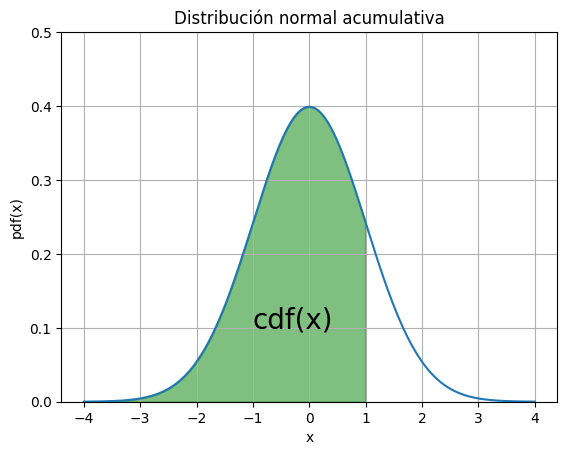

In [234]:
from scipy.stats import norm
fig, ax = plt.subplots()
# for distribution curve
x= np.arange(-4,4,0.001)
ax.plot(x, norm.pdf(x))
ax.set_title("Distribución normal acumulativa")
ax.set_xlabel('x')
ax.set_ylabel('pdf(x)')
ax.grid(True)
# for fill_between
px=np.arange(-4,1,0.01)
ax.set_ylim(0,0.5)
ax.fill_between(px,norm.pdf(px),alpha=0.5, color='g')
# for text
ax.text(-1,0.1,"cdf(x)", fontsize=20)
plt.show()

### Cálculo de probabilidades de una distribución normal



Calculemos $\text{cdf}(2)=\mathbb{P}(X<2)$ cuando $X\sim N(3,2^2)$.
$$Z = \frac{X-\mu}{\sqrt{\sigma^2}} \sim N(0,1)$$

In [235]:
norm.cdf(x=2, loc=3, scale=2) #v.a. con media=3 y st=2

np.float64(0.3085375387259869)

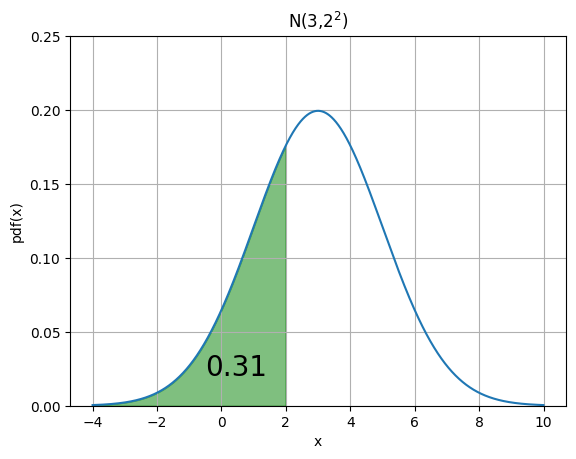

In [236]:
from scipy.stats import norm
fig, ax = plt.subplots()
# for distribution curve
x= np.arange(-4,10,0.001)
ax.plot(x, norm.pdf(x,loc=3,scale=2))
ax.set_title("N(3,$2^2$)")
ax.set_xlabel('x')
ax.set_ylabel('pdf(x)')
ax.grid(True)
# for fill_between
px=np.arange(-4,2,0.01)
ax.set_ylim(0,0.25)
ax.fill_between(px,norm.pdf(px,loc=3,scale=2),alpha=0.5, color='g')
# for text
ax.text(-0.5,0.02,round(norm.cdf(x=2, loc=3, scale=2),2), fontsize=20)
plt.show()

In [237]:
s=np.sqrt(2)
norm(1, s).cdf(2) - norm(1,s).cdf(0.5)

np.float64(0.3984131339906417)

Calculemos $\mathbb{P}(0.5<𝑋<2)$ cuando $X\sim N(1,2)$.

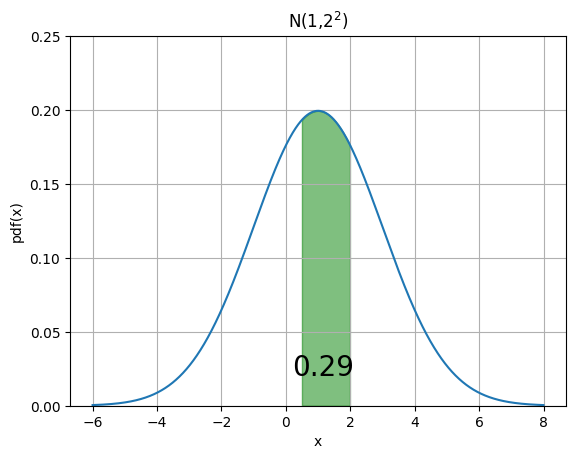

In [238]:
fig, ax = plt.subplots()
x= np.arange(-6,8,0.001)
ax.plot(x, norm.pdf(x,loc=1,scale=2))
ax.set_title("N(1,$2^2$)")
ax.set_xlabel('x')
ax.set_ylabel('pdf(x)')
ax.grid(True)
px=np.arange(0.5,2,0.01)
ax.set_ylim(0,0.25)
ax.fill_between(px,norm.pdf(px,loc=1,scale=2),alpha=0.5, color='g')
pro=norm(1, 2).cdf(2) - norm(1,2).cdf(0.5)
ax.text(0.2,0.02,round(pro,2), fontsize=20)
plt.show()

**Ejemplo importante** Si $Z\sim N(0,1)$, encuentra $\mathbb{P}(-1.93 < Z < 1.93)$. La probabilidad buscada es:


In [239]:
norm(0,1).cdf(1.93)-norm(0,1).cdf(-1.93)

np.float64(0.9463931622458901)

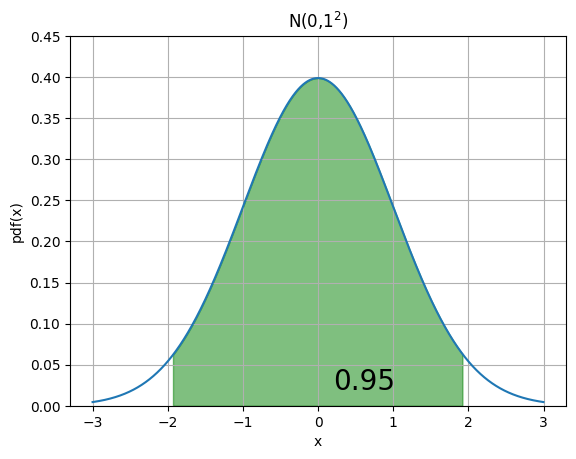

In [240]:
fig, ax = plt.subplots()
# for distribution curve
x= np.arange(-3,3,0.001)
ax.plot(x, norm.pdf(x,loc=0,scale=1))
ax.set_title("N(0,$1^2$)")
ax.set_xlabel('x')
ax.set_ylabel('pdf(x)')
ax.grid(True)
px=np.arange(-1.93,1.93,0.01)
ax.set_ylim(0,0.45)
ax.fill_between(px,norm.pdf(px,loc=0,scale=1),alpha=0.5, color='g')
pro=norm(0, 1).cdf(1.93) - norm(0,1).cdf(-1.93)
ax.text(0.2,0.02,round(pro,2), fontsize=20)
plt.show()

### Cálculo de probabilidades:
$\mathbb{P}(0<Z<b)$: Queremos calcular $\mathbb{P}(0<Z<0.43)$, lo cuál puede realizarse de la siguiente manera:
* Tablas de área a la derecha: $\mathbb{P}(0<Z<0.43) = 0.1664$

$\mathbb{P}(-b<Z<b)$: Queremos calcular $\mathbb{P}(-0.16<Z<0.16)$, lo cuál puede realizarse de la siguiente manera:
* Tablas de área a la derecha:  $\mathbb{P}(-0.16<Z<0.16) = \mathbb{P}(-0.16<Z<0)+\mathbb{P} (0<Z<0.16) = \mathbb{P}(0<Z<0.16)+\mathbb{P}(0<Z<0.16) = 2\mathbb{P}(0<Z<0.16) = 2(0.0636) = 0.1272$

$\mathbb{P}(Z<-b)$: Queremos calcular $\mathbb{P}(Z<-1.94)$, lo cuál puede realizarse de la siguiente manera:
* Tablas de área a la derecha: $\mathbb{P}(Z<-1.94) = \mathbb{P}(Z<0)+\mathbb{P}(-1.94<Z<0) = \mathbb{P}(Z<0) + \mathbb{P}(0<Z<1.94) = 0.5 - 0.4738 = 0.0262$

$\mathbb{P}(Z>-b)$: Queremos calcular $(Z>-0.07)$, lo cuál puede realizarse de la siguiente manera:
* Tablas de área a la derecha: $\mathbb{P}(Z>-0.07) = \mathbb{P}(-0.07<Z<0) + \mathbb{P}(Z>0) = \mathbb{P}(0<Z<0.07) + \mathbb{P}(Z>0) = 0.0279 + 0.5 = 0.5279$

## Variable aleatoria Gamma con parámetros $\alpha$ y $\lambda$.

 La distribución gamma se obtiene al considerar el tiempo que transcurre entre cierto número de ocurrencias de eventos que ocurren aleatoriamente en el tiempo

La función gamma $\Gamma:(0,\infty)\to \mathbb{R}$ está definida como
	$$\Gamma(\alpha)=\int_{0}^{\infty}t^{\alpha-1}e^{-t}dt.$$



*Propiedades de la función gamma*.
- $\Gamma(\alpha)<\infty$ para cualquier $\alpha>0$.
- $\Gamma(\alpha+1)=\alpha\Gamma(\alpha)$.
- Si $n\geq 1$ $\Gamma(n)=(n-1)!$
- $\Gamma\left(\frac{1}{2} \right)=\sqrt{\pi}$.



 Si $\alpha$ y $\lambda$ son reales positivos, decimos que una variable aleatoria $X$ tiene distribución gamma con parámetros $\alpha$ y $\lambda$ si tiene por función de densidad:
	$$\displaystyle f_{X}(x)=\begin{cases}
	\displaystyle \frac{\lambda^{\alpha}x^{\alpha-1}e^{-\lambda x} }{\Gamma(\alpha)} & x>0\\
	0 & \text{en otro caso}
	\end{cases}$$
En esta caso, escribimos la información anterior como $X\sim \Gamma(\alpha,\lambda) $


Ejemplo 1. Una computadora cuántica cuenta con un tipo de aparato de medición, el cual tiene un tiempo de vida que se distribuye exponencialmente, de tal manera que su tiempo promedio de vida es de  $1000$ horas. Si se utilizan $10$ de estos aparatos en forma consecutiva, uno de ellos después de que el anterior ya no funciona. ¿Cuál es la probabilidad de que alguno de los aparatos estará funcionando después de $10,000$ horas?


**Solución.**
Sea $X$ el tiempo total de vida de los $5$ aparatos, usados, como se indica, uno después del otro. Entonces $X\sim \Gamma(10, 0.001)$. Así,
$$\mathbb{P}(X>10000)=\int_{10000}^{\infty}\frac{(0.001)^{10}}{9!}x^{9}e^{-0.001x}dx=0.4579.$$

Ejemplo 2.  Consideremos un call center donde los tiempos entre llamadas son independientes y se distribuyen exponencialmente con una media de 3 minutos. Supongamos que queremos encontrar la probabilidad de que transcurran más de 30 minutos antes de recibir 10 llamadas.


**Solución.**
Sea $X$ el tiempo total para recibir $10$ llamadas. Dado que el tiempo medio entre llamadas es de $3$ minutos. Entonces $X \sim \Gamma(10, \frac{1}{3})$. Así
$$P(X > 30) = \int_{30}^{\infty} \frac{\left(\frac{1}{3}\right)^{10} x^{9} e^{-\frac{x}{3}}}{9!} \, dx = 0.45793.$$

**Nota.** Si $X\sim N(0,1)$, entonces $X^{2}\sim \Gamma\left(\frac{1}{2}, \frac{1}{2} \right)$.
En efecto, Para $z>0$, se tiene:
	$$F_{X^{2}}(z)=\mathbb{P}(X^2\leq z)=\mathbb{P}(-\sqrt{z}\leq X\leq \sqrt{z})=F_{X}(\sqrt{z})-F_{X}(-\sqrt{z}).$$
Por lo tanto,
$$f_{X^2}(z)=\frac{d F_{X^{2}}(z)}{dz}=\frac{1}{2\sqrt{z}}f_{X}(\sqrt{z})+\frac{1}{2\sqrt{z}}f_{X}(-\sqrt{z})=\frac{1}{\sqrt{z}}f_{X}(z).$$
Ahora,
$$f_{X}(\sqrt{z})=\frac{1}{\sqrt{2\pi}}e^{-\frac{1}{2}z}.$$


### Esperanza y Varianza

La esperanza, $\text{E}[X]$ para una variable aleatoria $X\sim Γ(\alpha, \lambda)$ es:

$$
\mathbb{E}(X) = \frac{\alpha}{\lambda}
$$
y su varianza es:
$$
\text{Var}(X) = \frac{\alpha}{\lambda^2}
$$



La distribución gamma es esencial en varios campos por su capacidad para modelar tiempos de espera y eventos con tasas constantes. Sus aplicaciones incluyen:

  * $\textbf{Teoría de colas y procesos estocásticos:}$ Modela el tiempo de espera hasta el k-ésimo evento.
  * $\textbf{Confiabilidad y análisis de supervivencia:}$ Utilizada para tiempos de fallo y eventos críticos en medicina.
  * $\textbf{Hidrología y meteorología:}$ Aplica en la modelación de precipitaciones acumuladas y tamaños de gotas.
  * $\textbf{Procesamiento de imágenes y señales:}$ En el ajuste de modelos a datos de intensidades.
  * $\textbf{Finanzas:}$ Para rendimientos de activos que no siguen distribuciones normales.
  * $\textbf{Biología y ecología:}$ Para tasas de crecimiento y tiempos entre eventos biológicos.
  * $\textbf{Física:}$ Describe tiempos de decaimiento y distribuciones de energía.


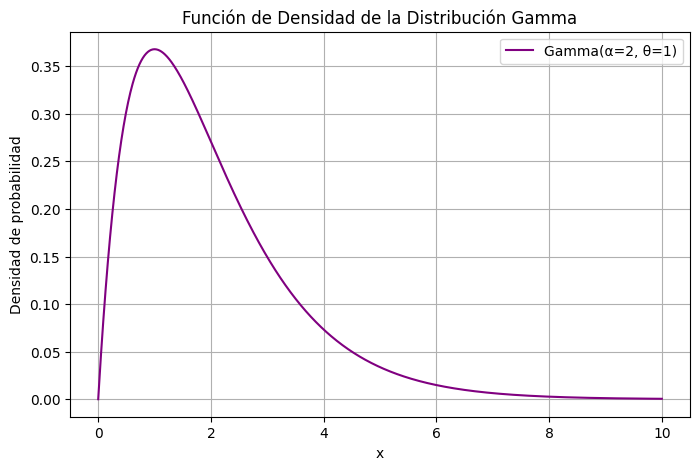

In [241]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# Parámetros de la distribución Gamma
shape_param = 2  # Parámetro de forma (k o α)
scale_param = 1  # Parámetro de escala (θ)

# Generar valores de x
x = np.linspace(0, 10, 1000)

# Calcular la PDF de la distribución Gamma
gamma_pdf = gamma.pdf(x, a=shape_param, scale=scale_param)

# Graficar la PDF de la distribución Gamma
plt.figure(figsize=(8, 5))
plt.plot(x, gamma_pdf, label=f'Gamma(α={shape_param}, θ={scale_param})', color='purple')
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.title('Función de Densidad de la Distribución Gamma')
plt.grid(True)
plt.legend()
plt.show()

- Si $\alpha = 1$, $\lambda > 0 \Rightarrow$ v.a. exponencial.

- Si $\lambda = \frac{1}{2}$, $\alpha = \frac{k}{2}$, $k \in \mathbb{Z}^{+} \Rightarrow$ ji-cuadrada.

- Si $\lambda > 1$ y $\alpha > 1 \Rightarrow$ Erlang $\Rightarrow$ aplicaciones.

**Ejemplo** Sea $X \sim \mathcal{N}(0,1)$. Demostrar que $ X^2 $ tiene una distribución gamma.

**Solución:** Para $z \geq 0$, se tiene que:

$$
\begin{align*}
F_{X^2}(z) &= P(X^2 \leq z) = P(-\sqrt{z} \leq X \leq \sqrt{z}) \\
&= F_X(\sqrt{z}) - F_X(-\sqrt{z}) \\
\end{align*}
$$
Derivando, obtenemos la función de densidad:

$$ f_{X^2}(z) = \frac{d}{dz} F_{X^2}(z) = \frac{1}{2\sqrt{z}} f_X(\sqrt{z}) + \frac{1}{2\sqrt{z}} f_X(-\sqrt{z}) $$

Como la densidad de $X$ es simétrica, se tiene que

$$ f_{X^2}(z) = \frac{1}{\sqrt{2\pi}} e^{-z/2} \frac{1}{2\sqrt{z}} = \frac{(1/2)^{1/2} z^{-1/2} e^{-z/2}}{\Gamma(1/2)}  \sim Gamma\left(\frac{1}{2}, \frac{1}{2}\right) $$


## Variable aleatoria Beta con parámetros $\alpha$ y $\beta$.


La distribución beta es una familia de distribuciones de probabilidad continua definida en el intervalo [0, 1]. Es particularmente útil para modelar variables que representan proporciones y porcentajes.

La función beta, $B(\alpha, \beta)$, se define como:

$$
B(\alpha, \beta) = \int_0^1 t^{\alpha-1}(1-t)^{\beta-1} dt = \frac{\Gamma(\alpha) \Gamma(\beta)}{\Gamma(\alpha + \beta)}
$$

La función de densidad de probabilidad de la distribución beta se expresa como:

$$
f_X(x) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha, \beta)},
$$
con $x\in (0,1)$.

**Notación.** $X\sim \text{Beta}(\alpha, \beta)$.



### Esperanza y Varianza
Si $X\sim \text{Beta}(\alpha, \beta)$, entonces
  $$\mathbb{E}[X] = \frac{\alpha}{\alpha + \beta}$$
y
  $$\text{Var}(X) = \frac{\alpha \beta}{(\alpha + \beta)^2 (\alpha + \beta + 1)}.$$





**Ejemplo.** Supongamos que un análisis sugiere que una nueva inversión tiene una alta probabilidad de éxito. Usando una distribución beta con $\alpha = 5$ y $\beta = 1$, entonces:

$$
f_{X}(x) = 5x^4, \quad \mathbb{E}[X] = \frac{5}{6}, \quad \text{Var}(X) = \frac{5}{252}
$$


**Aplicaciones en la Vida Real**

La distribución beta se utiliza en una variedad de campos, incluyendo:
- Finanzas: para modelar la variabilidad en tasas de retorno de inversiones.
- Mercadotecnia: para analizar proporciones de respuesta de consumidores.
- Ciencias de la salud: en la evaluación de la efectividad de tratamientos médicos.
- Ecología: para estimar proporciones en estudios de biodiversidad.

# Generación y uso de variables aleatorias

Daremos recopilación de métodos para generar variables aleatorias utilizados en simulación computacional. Se abordan distribuciones uniformes, exponenciales, normales, binomiales y Poisson, entre otras, así como técnicas como la transformada inversa y el método del rechazo.

Ejemplos comunes en simulación:
- Tiempo entre llegada de cada persona  
- Número de personas por minuto  
- Número de artículos por persona  
- Cantidad de dinero ganado cada hora  
- Tiempo de atención por cliente  
- Número de veces que la cajera solicita ayuda durante la jornada  
- Cantidad de gente que está formada  
- Número de personas que pagan con tarjeta

## Métodos de generación de números aleatorios rectangulares

La generación de variables aleatorias con esta distribución es importante porque las variables que tengan una distribución diferente, tendrán que usar a ésta como base.

- Cada posible resultado entre $a$ y $b$ tiene la misma probabilidad $1/n$.

Las variables generadas deben cumplir con:
- Los valores generados deben ser independientes y estar idénticamente distribuidos
- La secuencia generada debe ser lo más larga posible y ser reproducibles
- Debe permitir generar múltiples secuencias
- Que usen poca memoria

Históricamente se han usado cuatro tipos de métodos para generar sucesiones de números rectangulares:
- Métodos manuales
- Tablas de biblioteca
- Computación analógica
- Computación digital

### Generación pseudoaleatoria

La generación de los números aleatorios rectangulares debe realizarse a través de relaciones matemáticas de recurrencia. Por esta razón se consideran **pseudoaleatorios**, ya que el proceso para generarlos es determinístico.

Hay dos métodos que son los más utilizados para la generación. Ambos se basan en la siguiente definición:

**Definición.** Dos enteros $a$ y $b$ son congruentes módulo $m$ si su diferencia es un múltiplo entero de $m$ y se expresa como
$$𝑎 \equiv 𝑏 ( \text{𝑚o𝑑 } 𝑚)$$
Como consecuencia:
- $(a-b)$ es divisible entre $m$
- $a$ y $b$ dan el mismo residuo al ser divididos entre $m$


#### Método congruencial multiplicativo

Generar una secuencia de números pseudoaleatorios uniformes en el intervalo (0, 1) usando la siguiente fórmula recursiva:

$$n_{i+1} = a n_i \mod m$$
- $m$ debe ser tan grande como sea posible, dependiendo de los bits por palabra que maneje la computadora, descontando el bit del signo ($b$). Por lo tanto: $m = 2^b$
- $a$ debe satisfacer que $a \approx 2^{(b+1)/2}$ y que $a \equiv \pm 3 \mod 8$. La segunda expresión equivale a $( a-(\pm3 ) )$ es múltiplo de $8$.
- $n_0$: entero positivo impar menor a $m$
- El periodo será de longitud: $m/4$

In [242]:
# n0 : valor inicial
# a : multiplicador
# m : módulo (2^b)
# n : el numero que quiero generar

def multiplicativo(n0,a,m,n):
    secuencia = [] # lista vacía para ir guardando los números
    ni = n0 # iniciamos con un valor inicial
    # Repetimos n veces
    for i in range(n):
        ni = (a*ni) % m # fórmula recurrente
        secuencia.append(ni/m) # agrego el número a la lista normalizado (numeros entre (0,1))
    return secuencia

#### Método congruencial mixto

Este método genera números pseudoaleatorios con la fórmula:
$$n_{i+1} = (a n_i + c) \mod m$$

**Obs.** Se le llama “mixto” porque incluye una constante adicional $c$ (a diferencia del método multiplicativo).

- $m = 2^b$
- $a \approx 2^{(b-1)/2}$, $a \equiv 1 \mod 4$, es decir, $(a-1)$ es múltiplo de 4.
- $c$, $n_0$: enteros positivos impares menores a $m$
- Periodo: tiene longitud $m$

In [243]:
# n0 : valor inicial
# a : multiplicador
# c : constante (impar)
# m : módulo (2^b)
# n : el numero que quiero generar

def mixto(n0,a,c,m,n):
    secuencia = [] # lista vacía para ir guardando los números
    ni = n0 # iniciamos con un valor inicial
    # Repetimos n veces
    for i in range(n):
        ni = (a*ni + c) % m # fórmula recurrente
        secuencia.append(ni/m) # agrego el número a la lista normalizado (numeros entre (0,1))
    return secuencia

In [244]:
# Ejemplo:
m = 2**31
a = 1103515245 # a≡1 (mod 4)
c= 12345
n0 = 41
n = 100000

secuencia_mixto = mixto(n0,a,c,m,n)
print(secuencia_mixto)

[0.06844326015561819, 0.9992314944975078, 0.4621392320841551, 0.9174640052951872, 0.5820055874064565, 0.37821047520264983, 0.2048243023455143, 0.18477003322914243, 0.4875209955498576, 0.8468507858924568, 0.47256272472441196, 0.9521327749826014, 0.45746100787073374, 0.17842541774734855, 0.5796984285116196, 0.36512060137465596, 0.8805065592750907, 0.48256447864696383, 0.8824073132127523, 0.42976788664236665, 0.7212892072275281, 0.22954718535766006, 0.48902439698576927, 0.25073418812826276, 0.0422417176887393, 0.4445157307200134, 0.4918553400784731, 0.11126030096784234, 0.2813080260530114, 0.29036102583631873, 0.5642223432660103, 0.3636711877770722, 0.8792625730857253, 0.7580303172580898, 0.2664944212883711, 0.5991757833398879, 0.3503890158608556, 0.683006679173559, 0.9048520512878895, 0.06571367429569364, 0.3902683136984706, 0.8067103805951774, 0.2865361962467432, 0.8025986538268626, 0.11442618910223246, 0.10157212754711509, 0.21533170342445374, 0.46070915134623647, 0.02158996369689703, 

| **Método**     | **Fórmula**                            | **Ventajas**                                          | **Riesgos / Limitaciones**                                |
|----------------|----------------------------------------|-------------------------------------------------------|------------------------------------------------------------|
| Multiplicativo | $n_{i+1} = a n_i \mod m $           | Rápido, menos memoria                                 | Menor aleatoriedad, requiere $(a, m, n_0)$ bien elegidos |
| Mixto          | $ n_{i+1} = (a n_i + c) \mod m $     | Mejor distribución, periodo completo posible          | Más complejo, pero más robusto                             |
| NumPy (`uniform`) | Motor moderno y validado           | Alta calidad, probado, rápido                         | Caja negra, sin control del generador interno              |


## Metodos de generación de numeros aleatorios no rectangulares

#### Método de la transformada inversa

El método utiliza la función de distribución $F(x)$ de la distribución que se va a simular
$$F(x) = \int_{-\infty}^{x} f(t)\,dt$$

Como se sabe, los valores de $F(x)$ están en el intervalo $(0,1)$ al igual que los números rectangulares $U$.

El método genera un $U$ y trata de determinar el valor de la variable aleatoria para la cual $F(x)$ sea igual a $U$.

Si $U \in (0,1)$:
$$ F(x) = U \quad \Rightarrow \quad x = F^{-1}(U)$$

$\mathbf{Teorema}.$ Sea $X$ una variable aleatoria real. Supongamos que su función de distribución $F$ es estrictamente creciente (por lo que $F$ es una biyección de $\mathbb{R}$ sobre $(0,1)$ y podemos denotar por $F^{-1}$ a su inversa). Sea $U\sim \text{unif}[0,1]$. Entonces $F^{-1}(U)$ tiene la misma ley que $X$.

Si $F$ no es estrictamente creciente, hemos visto que el teorema precedente sigue siendo válido bajo la condición de definir
$$F^{-1}(u)=\inf\{ x\in \mathbb{R} : F(x)\geq u\},$$
la inversa generalizada de $F$.

In [245]:
# Vamos a generar una v.a. Bernoulli, usando una uniforme
# Sabemos que x\sim Ber(p), si f(x)= p^{x} * (1-p)^{1-x}
import random # números aleatorios
def bernoulli(p):
    U = random.random()  # U \sim Unif[0,1]
    if U <= p:
        return 1 # éxito
    else:
        return 0 # fracaso

In [246]:
# Simulamos n valores con p la probabilidad de éxito
p=0.3
n=10000
muestra = [bernoulli(p) for _ in range(n)]
print(muestra)

[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 

In [247]:
print(muestra[:20])

[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1]


In [248]:
print("El número de éxitos es:", sum(muestra))

El número de éxitos es: 2999


In [249]:
print("El promedio es:", sum(muestra) / n)

El promedio es: 0.2999


In [250]:
import plotly.express as px # Para visualizaciones interactivas
px.histogram(
    muestra,
    x = muestra,
    nbins = 2,
    title = "Simulaciones de una bernoulli con p=0.3",
    labels = {"x": "Valor de la Bernoulli (0-fracaso, 1-éxito)"}
)

## Ejemplo: Distribución exponencial

Sea $\lambda>0$, entonces a través del teorema se puede generar una v.a. exponencial.

Sea $U \sim Unif[0,1]$, entonces si $X\sim Exp(\lambda)$, entonces

$$f_{X}(x) = \lambda e^{-\lambda x}$$
y que
$$F_X(x) = 1 - e^{-\lambda x}$$

Sabemos que $1-e^{-\lambda x} = U$, entonces $1-U = e^{-\lambda x}$, y tomando logaritmo, se tiene que
$ \ln(1-U) = -\lambda x$ y como $U$ es uniforme entonces $U \sim 1-U$, por lo que depejando a $x$, se tiene que
$$ X = -\frac{\ln(U)}{\lambda} \sim Exp(\lambda) $$


In [251]:
import numpy as np
import plotly.graph_objects as go # con un mayor control
# Fijamos una semilla para reproducibilidad
np.random.seed(123)

# Damos el parámetro de la exponencial
lambd = 4

# Número de simulaciones
n = 10000

# Generamos n uniformes: U \sim Unif(0,1)
uniformes = np.random.random(n)

# Aplicamos la transformada inversa
# X = -ln(U) / lambd
exponenciales = -np.log(uniformes) / lambd

# Vamos a crear la curva de densidad teórica (exponencial)
# crea 300 valores igualmente espaciados entre 0 y el max(exponenciales)
x_vals = np.linspace(0, exponenciales.max(),300)
y_vals = lambd * np.exp(-lambd * x_vals) # densidad de la exponencial

fig = go.Figure()
# Se van agregando capas a la figura

# Agregamos el histograma de la simulacion
fig.add_trace(go.Histogram(
    x = exponenciales,
    nbinsx = 40,
    histnorm = 'probability density',
    marker_color = 'skyblue',
    name = 'Simulación'
))

# Agregamos la curva de densidad teórica
fig.add_trace(go.Scatter(
    x = x_vals,
    y = y_vals,
    mode = 'lines',
    name = 'Densidad teórica',
    line = dict(color='darkblue')
))

fig.update_layout(
    title = "Distribución exponencial simulada vs teórica (lambda = 4)",
    xaxis_title = 'x',
    yaxis_title = 'Densidad',
    bargap = 0.05 # espacio entre las barras
)

fig.show()

## Ejercicio: Distribución Uniforme Continua
$$f(x) = \frac{1}{b-a}, \quad a \leq x \leq b$$
$$F(x) = \frac{x-a}{b-a} = U \Rightarrow X = a + (b-a)U \sim Unif(a,b)$$

## Ejercicio: Distribución Cauchy

Simulemos la variable aleatoria de Cauchy de parámetro $1$ que tiene por función de densidad
$$f_{X}(x) = \frac{1}{\pi}\frac{1}{1+x^{2}}, \quad x\in\mathbb{R}$$

- Corroborar que la función así definida es una función de densidad de probabilidad

  $$ \int_\mathbb{R}f_X(x)dx = 1$$

- Encontrar $F_X = P(X\le x) = \int_{-\infty}^{x}f_{X}(t)dt$
- Crear una gráfica en Python que muestre su forma
- Generar v.a. Cauchy a partir de una uniforme

Por el teorema anterior, para $u\in (0,1)$
$$u=\frac{1}{\pi}\arctan(x)+\frac{1}{2} \qquad \text{si y sólo si} \qquad x=\tan\left({\pi}\left(u-\frac{1}{2} \right) \right).$$

In [252]:
import numpy as np
import scipy.integrate as integrate

# 1. Verify integral of PDF equals 1
pdf = lambda x: 1 / (np.pi * (1 + x**2))
val, err = integrate.quad(pdf, -np.inf, np.inf)
print(f"Integral of PDF from -inf to inf: {val} (err: {err})")

# 2. Verify CDF formula
# CDF(x) = 1/pi * arctan(x) + 1/2
cdf = lambda x: (1 / np.pi) * np.arctan(x) + 0.5

# Test CDF limits
print("CDF(-1000):", cdf(-1000))
print("CDF(0):", cdf(0))
print("CDF(1000):", cdf(1000))

# 3. Inverse transform method test
# u ~ Uniform(0,1) -> x = tan(pi * (u - 0.5))
np.random.seed(42)
u = np.random.uniform(0, 1, 100000)
x_sim = np.tan(np.pi * (u - 0.5))
print("Simulated median:", np.median(x_sim))

Integral of PDF from -inf to inf: 1.0 (err: 1.641073385039507e-10)
CDF(-1000): 0.0003183097800805168
CDF(0): 0.5
CDF(1000): 0.9996816902199195
Simulated median: 0.0019785211161359685


 1. Demostración: $f_X(x)$ es una función de densidad de probabilidad (FDP)Para que $f_X(x) = \frac{1}{\pi} \frac{1}{1+x^2}$ sea una FDP válida, debe cumplir dos condiciones:

 a) No negatividadPara todo $x \in \mathbb{R}$:$$1 + x^2 > 0 \implies \frac{1}{\pi(1+x^2)} > 0$$Por lo tanto, $f_X(x) > 0$ en todo su dominio.

 b) Integración a 1 sobre $\mathbb{R}$
 $$\int_{-\infty}^{\infty} f_X(x) \, dx = \int_{-\infty}^{\infty} \frac{1}{\pi(1+x^2)} \, dx = \frac{1}{\pi} \left[ \arctan(x) \right]_{-\infty}^{\infty}$$
 Calculando los límites:
 $$\lim_{x \to \infty} \arctan(x) = \frac{\pi}{2}, \quad \lim_{x \to -\infty} \arctan(x) = -\frac{\pi}{2}$$
 Sustituyendo:
 $$\int_{-\infty}^{\infty} f_X(x) \, dx = \frac{1}{\pi} \left( \frac{\pi}{2} - \left(-\frac{\pi}{2}\right) \right) = \frac{1}{\pi} (\pi) = 1$$

 2. Obtención de la Función de Distribución Acumulada $F_X(x)$

 La FDA se obtiene integrando la densidad desde $-\infty$ hasta $x$:
 $$F_X(x) = P(X \le x) = \int_{-\infty}^{x} f_X(t) \, dt = \int_{-\infty}^{x} \frac{1}{\pi(1+t^2)} \, dt$$

 $$F_X(x) = \frac{1}{\pi} \left[ \arctan(t) \right]_{-\infty}^{x} = \frac{1}{\pi} \left( \arctan(x) - \lim_{t \to -\infty} \arctan(t) \right)$$

 $$F_X(x) = \frac{1}{\pi} \left( \arctan(x) - \left(-\frac{\pi}{2}\right) \right) = \frac{1}{\pi} \arctan(x) + \frac{1}{2}$$

 3. Generación de la v.a. Cauchy mediante el Método de la Transformada Inversa

 Sea $U \sim \text{Uniforme}(0, 1)$. Para simular $X$ hacemos $U = F_X(X)$ y despejamos $X$:$$U = \frac{1}{\pi} \arctan(X) + \frac{1}{2}$$

 $$U - \frac{1}{2} = \frac{1}{\pi} \arctan(X)$$

 $$\pi \left( U - \frac{1}{2} \right) = \arctan(X)$$

 $$X = \tan \left( \pi \left( U - \frac{1}{2} \right) \right)$$

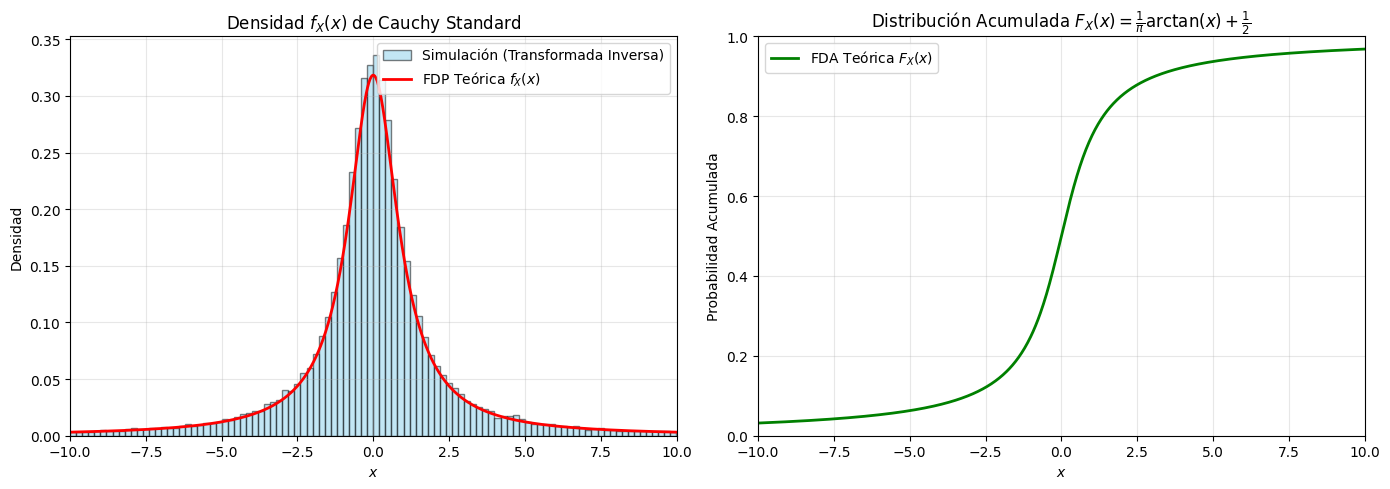

In [253]:
import matplotlib.pyplot as plt
import numpy as np

# Set de estilo y semilla
np.random.seed(42)

# --- 1. Definición teórica ---
f_X = lambda x: 1 / (np.pi * (1 + x**2))  # FDP
F_X = lambda x: (1 / np.pi) * np.arctan(x) + 0.5  # FDA

x_vals = np.linspace(-10, 10, 1000)

# --- 2. Simulación por Transformada Inversa ---
N = 50000
u = np.random.uniform(0, 1, N)
x_simulated = np.tan(np.pi * (u - 0.5))

# Filtramos valores extremos solo para la representación del histograma
x_sim_filtered = x_simulated[
    (x_simulated >= -10) & (x_simulated <= 10)
]  # Las colas son muy pesadas

# --- 3. Gráficas ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de la FDP (Teoría vs Simulación)
axes[0].hist(
    x_sim_filtered,
    bins=100,
    density=True,
    alpha=0.5,
    color="skyblue",
    edgecolor="black",
    label="Simulación (Transformada Inversa)",
)
axes[0].plot(x_vals, f_X(x_vals), "r-", lw=2, label="FDP Teórica $f_X(x)$")
axes[0].set_title("Densidad $f_X(x)$ de Cauchy Standard")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("Densidad")
axes[0].set_xlim(-10, 10)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfica de la FDA Teórica
axes[1].plot(x_vals, F_X(x_vals), "g-", lw=2, label="FDA Teórica $F_X(x)$")
axes[1].set_title(
    "Distribución Acumulada $F_X(x) = \\frac{1}{\\pi} \\arctan(x) + \\frac{1}{2}$"
)
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("Probabilidad Acumulada")
axes[1].set_xlim(-10, 10)
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Ley de los Grandes Números



## Antecedentes Históricos y Ejemplo Binomial

Ley de los Grandes Números (LGN): \
Formulada por Jacob Bernoulli (1730).\
Formalización por Kolmogorov (1933).\

Definición: Establece que el promedio muestral converge al valor esperado conforme el tamaño de la muestra aumenta.Teorema del Límite Central (TLC):\
Utilizado por primera vez para aproximar una distribución binomial a una normal.\


Ejemplo práctico: Lanzamos una moneda $5000$ veces y sea $X$ el número de soles:$$X \sim \text{Bin}\left(5000, \frac{1}{2}\right)$$Podemos calcular la probabilidad:$$\mathbb{P}(3500 \le X \le 4500) = {\sum_{i=3500}^{4500} \binom{5000}{i} \left(\frac{1}{2}\right)^i \left(1 - \frac{1}{2}\right)^{5000-i}}$$Parámetros de la distribución:$$\mathbb{E}[X] = np = 5000\left(\frac{1}{2}\right) = 2500$$$$\text{Var}(X) = np(1-p) = 5000\left(\frac{1}{2}\right)\left(\frac{1}{2}\right) = 1250$$Estandarizando la variable:$$Z = \frac{X - \mathbb{E}[X]}{\sqrt{\text{Var}(X)}} \sim \mathcal{N}(0,1)$$$$\mathbb{P}(3500 \le X \le 4500) = \mathbb{P}\left(\frac{3500 - 2500}{\sqrt{1250}} \le Z \le \frac{4500 - 2500}{\sqrt{1250}}\right)$$$$= \mathbb{P}(28.28 \le Z \le 56.56) \approx 0 \
$$Vectores Aleatorios y Densidades Conjuntas\
 Mapeo univariable: $\Omega \xrightarrow{\quad X \quad} \mathbb{R}$ con $x_1 = X(\omega_1)$ y función de distribución $F_X(x)$.\
 Mapeo bivariado: $\Omega \xrightarrow{\quad (X, Y) \quad} \mathbb{R}^2$ con $(x, y) = X(\omega_1)$ y $F_{(X, Y)}(x, y) = \mathbb{P}(X \le x, Y \le y)$.\

 Vector aleatorio de dimensión $n$:$$X : \Omega \rightarrow \mathbb{R}^n$$$$X = (X_1, \dots, X_n)$$Caso Discreto para $(X, Y)$ vector aleatorio discreto:$$f_{(X,Y)}(x,y) = \begin{cases} \mathbb{P}(X=x, Y=y) & , \, (x,y) \in R_{(X,Y)} = R_X \times R_Y \\ 0 & , \, \text{e.o.c} \end{cases}$$Propiedades: $f_{(X,Y)} \ge 0$ y $\sum_x \sum_y f_{(X,Y)}(x,y) = 1$.\

 Caso Continuo para $(X,Y)$ vector aleatorio continuo:$f_{(X,Y)} > 0$ es no negativa.$\int_{\mathbb{R}} \int_{\mathbb{R}} f_{(X,Y)}(x,y) \, dx \, dy = 1$

 Funciones de Densidad Marginal.

 A partir de la densidad conjunta se obtienen $f_X$ y $f_Y$:

 Discreto:$f_X(x) = \sum_y f_{(X,Y)}(x,y) \longleftarrow \text{densidad marginal de } X$$f_Y(y) = \sum_x f_{(X,Y)}(x,y) \longleftarrow \text{densidad marginal de } Y$

 Continuo:$f_X(x) = \int_{\mathbb{R}} f_{(X,Y)}(x,y) \, dy$$f_Y(y) = \int_{\mathbb{R}} f_{(X,Y)}(x,y) \, dx$3.

 Independencia y Ley de los Grandes Números (LGN)Independencia:
 Decimos que $X$ y $Y$ son v.a. independientes si:$$\mathbb{P}(X=x, Y=y) = \mathbb{P}(X=x) \mathbb{P}(Y=y)$$En el caso continuo:$$f_{(X,Y)}(x,y) = f_X(x) f_Y(y)$$Generalización ($n$ variables): $X_1, X_2, \dots, X_n$ son independientes si:$$f_X(x_1, \dots, x_n) = f_{X_1}(x_1) \cdots f_{X_n}(x_n) = \prod_{i=1}^{n} f_{X_i}(x_i)$$Si además tienen la misma distribución:$\mathbb{E}[X_i] = \mu$ (misma esperanza)$\text{Var}(X_i) = \sigma^2$ (misma varianza)Se denotan como v.a.i.i.d. (variables aleatorias independientes e idénticamente distribuidas).Desarrollo de la LGNSea $S_n = \sum_{i=1}^{n} X_i = X_1 + \cdots + X_n$:$$\mathbb{E}[S_n] = \mathbb{E}\left[\sum X_i\right] = \sum \mathbb{E}[X_i] = \sum_{i=1}^{n} \mu = n\mu$$$$\text{Var}(S_n) = \text{Var}\left(\sum X_i\right) \stackrel{\text{indep}}{=} \sum \text{Var}(X_i) = \sum \sigma^2 = n\sigma^2$$Definiendo el promedio aritmético $M_n = \frac{S_n}{n}$:$$M_n \xrightarrow[n \to \infty]{} \mathbb{E}[X_i] = \mu \quad (\text{LGN})$$LGN Débil: Convergencia en probabilidad.LGN Fuerte: Convergencia casi segura.4. Teorema del Límite Central (TLC) y Ejemplos AsintóticosEstandarizando la suma de variables v.a.i.i.d.:$$Z_n = \frac{S_n - n\mu}{\sqrt{n\sigma^2}} = \frac{S_n - n\mu}{\sqrt{n}\sigma} \sim \mathcal{N}(0,1)$$Convergencia a una normal (convergencia en distribución):$$Z_n \xrightarrow{\quad \mathcal{D} \quad} Z \sim \mathcal{N}(0,1)$$$$\begin{aligned} X_1, \dots, X_n &\xrightarrow[n \to \infty]{} X \\ F_{X_1}(x_1), \dots, F_{X_n}(x_n) &\xrightarrow[n \to \infty]{} F_X(x) \end{aligned}$$Ejemplos:Si $X_1, \dots, X_n \sim \text{Ber}(p)$ v.a.i.i.d. $\implies \frac{X_1 + \cdots + X_n}{n} \rightarrow \mu = p$Si $X_1, \dots, X_n \sim \text{Unif}(0,1)$ v.a.i.i.d. $\implies \frac{S_n}{n} \rightarrow \mu = \frac{1}{2}$

## Implementación Computacional en Python

A continuación se presenta la simulación del problema de la aguja de Buffon para la estimación del número $\pi$, evaluando el comportamiento de la convergencia a lo largo de $100,000$ lanzamientos.

Estimación de pi: [3.076923076923077, 3.0557677616501144, 3.080082135523614, 3.1140521603736864, 3.1298904538341157, 3.113648157758173, 3.125, 3.1360250882007055, 3.1315240083507305, 3.138239447669857, 3.1218958422023557, 3.1335683509596555, 3.1246244441773827, 3.1201248049921997, 3.1181789834736513, 3.1195164749463835, 3.120411160058737, 3.1222896790980053, 3.1229454306377384, 3.1257325935766196, 3.1240702171972625, 3.117692907248636, 3.1135779071341547, 3.116883116883117, 3.113131187348235, 3.1096758760913765, 3.110599078341014, 3.112148493942425, 3.1094193963437515, 3.112033195020747, 3.1143258991360256, 3.114506788651516, 3.1129138760494293, 3.114408720344417, 3.1136019927052754, 3.1124367786279343, 3.1112045406768973, 3.1099107946640476, 3.1095519055971934, 3.1118717908822155, 3.1137269793051074, 3.1174614956392652, 3.1192194697326903, 3.1160369675294786, 3.1194759280440887, 3.1194900311949003, 3.1214717407186026, 3.1228652288474676, 3.1240038253108064, 3.1273455091318487, 3.12768

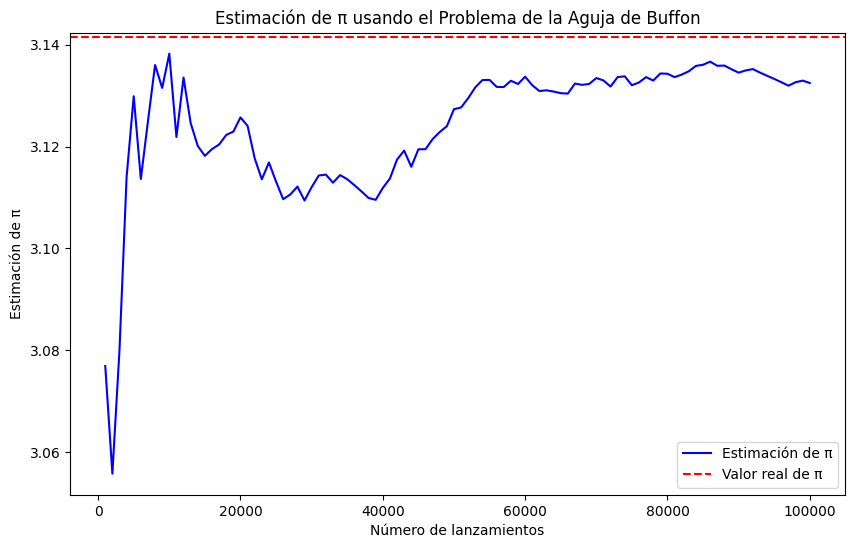

In [254]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del problema
# Distancia entre las lineas paralelas de 1
# Longitud de la aguja de 1

L = 1 # longitud L<=d
d = 1 #distancia
num_lanzamientos = 100000

step = 1000 # numero de pasos

# Creamos listas vacías para guardar los resultados
pi_estimados = []
lanzamientos_realizados = []

# Contamos los cruces de la linea para saber cuantas agujas cruzan una línea
cruces = 0

# Simulación de los lanzamientos de la aguja y la estimación de pi
for i in range(1,num_lanzamientos+1):
    # Posicion del centro de la aguja
    centro = np.random.uniform(0,d/2)

    # Ángulo aleatorio entre 0 y pi
    angulo = np.random.uniform(0,np.pi)

    # Distancia desde el centro de la aguja hasta la línea más cercana
    distancia = (L/2) * np.sin(angulo)

    # Verificamos si la aguja cruza una línea
    if centro <= distancia:
        cruces += 1 # incrementar el contador

    # Estimación de pi
    if i % step == 0 and cruces > 0:
        pi_estimado = (2 * L * i) / (d * cruces)
        pi_estimados.append(pi_estimado)
        lanzamientos_realizados.append(i)

print(f"Estimación de pi: {pi_estimados}")

# Graficamos la estimación de pi
plt.figure(figsize=(10,6))
plt.plot(lanzamientos_realizados, pi_estimados, label='Estimación de π', color='blue')
plt.axhline(np.pi, color='red', linestyle='--', label='Valor real de π')
plt.xlabel('Número de lanzamientos')
plt.ylabel('Estimación de π')
plt.title('Estimación de π usando el Problema de la Aguja de Buffon')
plt.legend()
plt.show()

# Conclusiones


## Variables aleatorias discretas
Una variable aleatoria discreta puede tomar un conjunto finito o numerable de valores. Cada resultado posible posee una probabilidad asociada descrita mediante una función de probabilidad. Estas distribuciones resultan especialmente útiles cuando el fenómeno observado consiste en contar eventos.
###Distribución uniforme discreta
La distribución uniforme discreta surge cuando todos los valores posibles tienen la misma probabilidad de ocurrir.
Entre sus propiedades destaca la equiprobabilidad de todos los resultados y la simetría alrededor de su media.

###Distribución Bernoulli
La distribución Bernoulli modela experimentos con únicamente dos posibles resultados: éxito o fracaso. Se utiliza para representar situaciones como aprobar o reprobar una inspección de calidad.

Una propiedad importante en que constituye el bloque básico de la distribución binomial.
Si la probabilidad de que una pieza sea defectuosa es 0.03, la probabilidad de observar una pieza defectuosa en una inspección individual es precisamente 0.03.

Cuando se repite un experimento Bernoulli varias veces bajo condiciones idénticas e independientes, se obtiene la distribución binomial. Esta distribución permite responder preguntas relacionadas con el número de éxitos observados dentro de una cantidad fija de intentos. En un contexto financiero podría utilizarse para estimar cuántos clientes aceptarán una oferta comercial entre un conjunto previamente contactado. Su esperanza se relaciona con el número esperado de éxitos y su varianza depende tanto del número de ensayos como de la probabilidad de éxito. La representación gráfica muestra una serie de probabilidades distribuidas alrededor de los valores más probables. Un ejercicio frecuente consiste en calcular la probabilidad de que exactamente cierto número de personas acepte una promoción.

### Distribución geométrica
Describe cuántos intentos se requieren hasta observar el primer éxito. Resulta útil para analizar procesos donde interesa el tiempo de espera hasta que ocurre un evento. Pensemos en el número de llamadas realizadas antes de concretar una venta. Su esperanza se interpreta como el número promedio de intentos necesarios, mientras que la varianza mide la dispersión del tiempo de espera. En Python suele representarse mediante barras decrecientes que reflejan la reducción gradual de probabilidades conforme aumentan los intentos requeridos.

###Distribución de Poisson
Se utiliza para modelar conteos de eventos que ocurren de manera independiente dentro de un intervalo determinado de tiempo o espacio. Es común en áreas como telecomunicaciones, logística y administración de operaciones. Puede emplearse para estudiar el número de clientes que ingresan a una tienda por hora o la cantidad de reclamaciones recibidas diariamente. Una característica interesante es que la esperanza y la varianza tienen el mismo valor numérico. Su gráfica presenta una forma asimétrica para tasas pequeñas y una apariencia más cercana a la normal cuando la tasa aumenta. Un ejercicio clásico consiste en estimar la probabilidad de recibir cierto número de llamadas en una hora.

###Distribución binomial negativa
Esta amplía la idea de la geométrica al considerar el número de ensayos requeridos para alcanzar varios éxitos. Aparece en estudios de confiabilidad y en fenómenos donde existe sobredispersión respecto a la distribución Poisson. Su esperanza representa el promedio de intentos necesarios para alcanzar una cantidad objetivo de éxitos. La visualización muestra probabilidades concentradas alrededor de un intervalo relativamente amplio. Un ejercicio útil consiste en analizar cuántas llamadas comerciales se necesitan para concretar varias ventas.

###Distribución hipergeométrica
Modela situaciones de muestreo sin reemplazo. A diferencia de la binomial, las probabilidades cambian después de cada extracción. Esto ocurre cuando se seleccionan piezas de un lote finito para inspección de calidad. La esperanza depende de la proporción de elementos de interés presentes en la población y la varianza incorpora un ajuste asociado al tamaño finito de dicha población. Una aplicación práctica consiste en estimar la probabilidad de hallar cierto número de artículos defectuosos dentro de una muestra seleccionada para auditoría.

## Variables aleatorias continuas

Las variables aleatorias continuas permiten representar fenómenos medidos en escalas numéricas continuas, como tiempos, distancias, pesos o concentraciones. En estos casos, el interés se centra en intervalos de valores más que en resultados aislados.

###Distribución uniforme continua
Describe situaciones donde todos los valores dentro de un intervalo poseen la misma densidad de probabilidad. Puede utilizarse para representar tiempos de llegada cuando no existe información adicional que sugiera preferencia por alguna región del intervalo. Su esperanza corresponde al punto medio y la varianza depende de la longitud del intervalo. En Python suele visualizarse mediante una línea horizontal constante sobre el rango de interés. La simulación consiste en generar observaciones aleatorias distribuidas uniformemente dentro del intervalo seleccionado.

###Distribución normal
Ocupa una posición central dentro de la estadística. Numerosos fenómenos naturales y sociales presentan comportamientos aproximados a esta distribución debido a la acumulación de múltiples efectos pequeños e independientes. Las calificaciones de grandes grupos de estudiantes, errores de medición y diversas características biológicas suelen acercarse a este modelo. La esperanza define el centro de la distribución y la varianza controla la dispersión. La representación gráfica adopta la conocida forma de campana. En simulaciones, suele compararse el histograma de datos generados con la curva teórica para evaluar la concordancia entre ambos.

###Distribución exponencial
Se emplea para modelar tiempos de espera entre eventos independientes que ocurren a una tasa constante. Resulta común en estudios de confiabilidad, mantenimiento y análisis de colas. Puede utilizarse para representar el tiempo entre llegadas de clientes o entre fallas de un sistema. La característica más conocida de esta distribución es la propiedad de falta de memoria, según la cual el tiempo futuro no depende del tiempo ya transcurrido. Su gráfica presenta una disminución continua conforme aumentan los valores observados.

###Distribución gamma
Generaliza a la exponencial y permite modelar tiempos acumulados hasta que ocurre una cantidad determinada de eventos. Su flexibilidad la convierte en una alternativa frecuente para analizar fenómenos de espera y procesos de riesgo. Dependiendo de sus parámetros puede adoptar formas muy distintas, desde distribuciones altamente asimétricas hasta comportamientos más cercanos a la normal. En simulaciones suele emplearse para representar tiempos de servicio o costos agregados.


###Función generadora de momentos

La función generadora de momentos constituye una herramienta que permite resumir información importante sobre una distribución en una sola expresión matemática. Según Mood, Graybill y Boes (1974), una de sus principales ventajas consiste en que los momentos, como la esperanza y la varianza, pueden obtenerse a partir de ella mediante procedimientos analíticos sistemáticos.

Desde una perspectiva práctica, la FGM permite identificar distribuciones, estudiar sumas de variables aleatorias independientes y derivar propiedades sin recurrir constantemente a cálculos directos sobre la función de probabilidad o de densidad. No obstante, existe una limitación importante: no todas las distribuciones poseen una función generadora de momentos definida para los valores requeridos.

###Función característica

La función característica cumple un papel semejante al de la FGM, aunque presenta una ventaja notable: siempre existe para cualquier distribución de probabilidad. Casella y Berger (2002), Shao (2003) y DasGupta (2008) muestran que esta herramienta resulta especialmente útil en teoría asintótica y en demostraciones relacionadas con convergencia de distribuciones.

En la práctica, la función característica facilita el estudio de sumas de variables aleatorias y proporciona una vía elegante para demostrar resultados de gran alcance como el Teorema Central del Límite. Aunque su interpretación directa suele ser menos intuitiva que la de la FGM, su utilidad teórica es considerable.

###Ley de los Grandes Números

La Ley de los Grandes Números explica por qué los promedios observados en muestras grandes tienden a estabilizarse alrededor del valor esperado teórico. Esta idea justifica gran parte de la estadística aplicada y de la simulación computacional.

Imaginemos una institución financiera interesada en estimar la proporción de clientes que incumplen un pago. Si solo analiza unos cuantos casos, la estimación puede variar de manera importante. Al incorporar miles de observaciones, el promedio observado suele acercarse al valor real del parámetro poblacional. La ley no garantiza que cada observación individual sea cercana al promedio, sino que el comportamiento agregado se vuelve cada vez más estable.

Desde una perspectiva aplicada, este resultado explica por qué las compañías de seguros, los bancos y las empresas de manufactura pueden construir estimaciones confiables cuando trabajan con grandes volúmenes de información. También ayuda a entender por qué los experimentos de simulación mejoran su precisión al incrementar el número de réplicas.

###Teorema Central del Límite

Constituye uno de los resultados más influyentes de la estadística moderna. Establece que, bajo ciertas condiciones, la distribución de los promedios muestrales tiende a aproximarse a una distribución normal conforme aumenta el tamaño de la muestra, aun cuando la distribución original no sea normal.

Podemos observar este fenómeno mediante simulación. Si generamos numerosas muestras de una distribución claramente asimétrica, como la exponencial, y calculamos los promedios de cada muestra, la distribución de esos promedios adquiere gradualmente una forma similar a la campana normal. Mientras mayor sea el tamaño de las muestras, más evidente será este comportamiento.

La relevancia práctica del TCL es enorme porque permite utilizar procedimientos inferenciales basados en la distribución normal en una amplia variedad de contextos. Buena parte de los intervalos de confianza y pruebas de hipótesis empleados en investigación, finanzas, ingeniería y ciencias sociales descansan en esta propiedad asintótica.
